# 1. Problem Definition

## 1.1 Business Context
An FMCG company that entered the instant noodles market two years ago is currently facing critical challenges in balancing demand and supply across its nationwide warehouse network. The current operational mismatch between regional demand and inventory supply has led to:
* **Wastage and Excess Inventory:** Resulting in higher storage costs in certain regions.
* **Missed Sales Opportunities:** Demand exceeding supply in other regions, leading to stockouts.

To remain competitive in this dynamic sector, the company requires a data-driven approach to align production with regional demand patterns.

## 1.2 Objectives
This analysis focuses on two distinct but complementary objectives:

### Primary Objective: Demand Forecasting (Supervised Regression)
The core task is to build a predictive model using historical data to determine the **optimum quantity of product (`product_wg_ton`)** to ship to each warehouse. This will enable the company to:
* Minimize inventory holding costs.
* Drastically reduce stockout events.
* Optimize supply chain efficiency.

### Secondary Objective: Regional Strategy (Unsupervised/Pattern Analysis)
The secondary task involves analyzing demand patterns across different zones and locations. This insight will help management:
* Identify high-growth vs. saturated regions.
* Design and deploy **targeted advertisement campaigns** to drive higher sales in specific areas.

## 1.3 Success Metrics
To evaluate the success of this project, we will use the following metrics:

| Metric | Application | Why it Matters |
| :--- | :--- | :--- |
| **RMSE** | Demand Forecasting | Penalizes large forecasting errors, which are costly in supply chains. |
| **MAE** | Demand Forecasting | Provides an interpretable average error in "tons" for stakeholders. |
| **Silhouette Score** | Regional Segmentation | Ensures that our marketing clusters are well-defined and actionable. |

---
*This notebook aims to transform raw historical sales data into a strategic roadmap for warehouse management and regional marketing.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set visualization style for consistency
import warnings
warnings.filterwarnings('ignore')

# Set overall style and color palette for presentation-ready charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 16})

import scipy.stats as stats


In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/shayanazmi05/supply-chain-data/supply_chain_data.csv')

# Display the first 5 rows to understand the feature structure
print("First 5 rows:")
display(df.head())

# Check basic dataset info (data types, missing values, memory usage)
print("\nDataset Info:")
df.info()

First 5 rows:


,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 25000 non-null  object 
 1   WH_Manager_ID                 25000 non-null  object 
 2   Location_type                 25000 non-null  object 
 3   WH_capacity_size              25000 non-null  object 
 4   zone                          25000 non-null  object 
 5   WH_regional_zone              25000 non-null  object 
 6   num_refill_req_l3m            25000 non-null  int64  
 7   transport_issue_l1y           25000 non-null  int64  
 8   Competitor_in_mkt             25000 non-null  int64  
 9   retail_shop_num               25000 non-null  int64  
 10  wh_owner_type                 25000 non-null  object 
 11  distributor_num               25000 non-null  int64  
 12  flood_impacted                25000 non-null 

# 3. Data Cleaning and Preprocessing

## 3.1 Handling Missing Values & Shadow Flag Engineering
Our data audit revealed significant missing data in `wh_est_year` (~48%), alongside minor gaps in `workers_num` and `approved_wh_govt_certificate`. 

Instead of dropping `wh_est_year`—which would discard vital operational signals regarding whether a facility is a temporary leased depot versus a legacy flagship hub—we apply **Missingness Indicator (Shadow Flag) Engineering**:
1. Create a binary shadow flag (`est_year_missing`) to explicitly capture the fact that the establishment year is unknown.
2. Impute missing years with the median establishment year to calculate `wh_age` without skewing distribution variance.
3. Impute minor missing values in `workers_num` with the median and fill missing certificates with `'None'`.

In [3]:
# 1. Shadow Flag Engineering for Warehouse Establishment Year
# Captures MNAR (Missing Not At Random) patterns (e.g., third-party rented depots)
df['est_year_missing'] = np.where(df['wh_est_year'].isnull(), 1, 0)

# 2. Convert Establishment Year to Warehouse Age
# We calculate age using a baseline year (e.g., 2023) and impute missing values with the median year
current_year = 2023
median_year = df['wh_est_year'].median()

df['wh_est_year_imputed'] = df['wh_est_year'].fillna(median_year)
df['wh_age'] = current_year - df['wh_est_year_imputed']

# 3. Handle remaining missing values
df['workers_num'] = df['workers_num'].fillna(df['workers_num'].median())
df['approved_wh_govt_certificate'] = df['approved_wh_govt_certificate'].fillna('None')

# Drop the raw and intermediate year columns as they are now fully captured by age and the shadow flag
df = df.drop(columns=['wh_est_year', 'wh_est_year_imputed'])

# Verify all missing values have been cleanly resolved
print("Remaining missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values per column:
Series([], dtype: int64)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 25000 non-null  object 
 1   WH_Manager_ID                 25000 non-null  object 
 2   Location_type                 25000 non-null  object 
 3   WH_capacity_size              25000 non-null  object 
 4   zone                          25000 non-null  object 
 5   WH_regional_zone              25000 non-null  object 
 6   num_refill_req_l3m            25000 non-null  int64  
 7   transport_issue_l1y           25000 non-null  int64  
 8   Competitor_in_mkt             25000 non-null  int64  
 9   retail_shop_num               25000 non-null  int64  
 10  wh_owner_type                 25000 non-null  object 
 11  distributor_num               25000 non-null  int64  
 12  flood_impacted                25000 non-null  int64  
 13  f

In [5]:
print(df)

      Ware_house_ID WH_Manager_ID Location_type WH_capacity_size   zone  \
0         WH_100000     EID_50000         Urban            Small   West   
1         WH_100001     EID_50001         Rural            Large  North   
2         WH_100002     EID_50002         Rural              Mid  South   
3         WH_100003     EID_50003         Rural              Mid  North   
4         WH_100004     EID_50004         Rural            Large  North   
...             ...           ...           ...              ...    ...   
24995     WH_124995     EID_74995         Rural            Small  North   
24996     WH_124996     EID_74996         Rural              Mid   West   
24997     WH_124997     EID_74997         Urban            Large  South   
24998     WH_124998     EID_74998         Rural            Small  North   
24999     WH_124999     EID_74999         Rural              Mid   West   

      WH_regional_zone  num_refill_req_l3m  transport_issue_l1y  \
0               Zone 6          

3.2 Strategic Feature Engineering
To serve both our Primary Objective (Demand Forecasting) and Secondary Objective (Regional Marketing Segmentation), we engineer domain-specific features before encoding:

wh_age_tier: Categorizes warehouses by maturity to help marketing teams identify "Emerging Growth" versus "Saturated Legacy" markets.

Market_Density_Index: Measures retail concentration relative to distributor network size.

Worker_Efficiency_Index: Proxies operational throughput capacity per worker.

In [6]:
# 1. Warehouse Age Tiers (Required for marketing & interaction feature)
df['wh_age_tier'] = pd.cut(
    df['wh_age'], 
    bins=[-1, 5, 15, 100], 
    labels=['Modern (<5 yrs)', 'Established (5-15 yrs)', 'Legacy (>15 yrs)']
)

# 2. Market Density Index (Proxy for regional retail demand pressure)
df['Market_Density_Index'] = df['retail_shop_num'] / (df['distributor_num'] + 1)

# 3. Worker Efficiency Ratio (Operational capacity normalization)
df['Worker_Efficiency_Index'] = df['WH_capacity_size'].map({'Small': 1, 'Mid': 2, 'Large': 3}) / (df['workers_num'] + 1)

# 4. Explicit EDA Interaction Feature (Capacity x Age Tier)
df['capacity_x_age_tier'] = df['WH_capacity_size'].astype(str) + "_" + df['wh_age_tier'].astype(str)

print("✅ All engineered features created successfully without KeyError!")

✅ All engineered features created successfully without KeyError!


In [7]:
# 2. Market Density Ratio (Collapse high-VIF components into a single signal)
df['Market_Density_Index'] = df['retail_shop_num'] / (df['distributor_num'] + 1)
# NOTE: we deliberately do NOT drop retail_shop_num / distributor_num here.
# The EDA cells below (correlation heatmap, VIF audit) need the raw columns to
# actually show WHY they should be collapsed. They get dropped safely right
# before modeling instead (see the 'Target Leakage Remediation' cell).

# 3. Worker Efficiency Ratio (Operational capacity normalization)
df['Worker_Efficiency_Index'] = df['WH_capacity_size'].map({'Small': 1, 'Mid': 2, 'Large': 3}) / (df['workers_num'] + 1)

# 4. Explicit EDA Interaction Feature (Capacity x Age Tier)
df['capacity_x_age_tier'] = df['WH_capacity_size'].astype(str) + "_" + df['wh_age_tier'].astype(str)

print("New features successfully engineered with VIF redundancy removed & explicit interactions added.")

New features successfully engineered with VIF redundancy removed & explicit interactions added.


In [8]:
df.head(10)

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton,est_year_missing,wh_age,wh_age_tier,Market_Density_Index,Worker_Efficiency_Index,capacity_x_age_tier
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,A,5,15,17115,1,14.0,Established (5-15 yrs),186.040000,0.033333,Small_Established (5-15 yrs)
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,A,3,17,5074,1,14.0,Established (5-15 yrs),129.520833,0.093750,Large_Established (5-15 yrs)
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,A,6,22,23137,1,14.0,Established (5-15 yrs),66.246154,0.052632,Mid_Established (5-15 yrs)
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,A+,3,27,22115,1,14.0,Established (5-15 yrs),117.647059,0.090909,Mid_Established (5-15 yrs)
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,C,6,24,24071,0,14.0,Established (5-15 yrs),110.232558,0.115385,Large_Established (5-15 yrs)
5,WH_100005,EID_50005,Rural,Small,West,Zone 1,8,0,2,5053,...,A+,3,3,32134,0,14.0,Established (5-15 yrs),132.973684,0.027778,Small_Established (5-15 yrs)
6,WH_100006,EID_50006,Rural,Large,West,Zone 6,8,0,4,4449,...,B,3,6,30142,0,13.0,Established (5-15 yrs),114.076923,0.107143,Large_Established (5-15 yrs)
7,WH_100007,EID_50007,Rural,Large,North,Zone 5,1,0,4,7183,...,C,6,24,24093,1,14.0,Established (5-15 yrs),156.152174,0.125000,Large_Established (5-15 yrs)
8,WH_100008,EID_50008,Rural,Small,South,Zone 6,8,1,4,5381,...,A+,5,2,18082,0,10.0,Established (5-15 yrs),125.139535,0.043478,Small_Established (5-15 yrs)
9,WH_100009,EID_50009,Rural,Small,South,Zone 6,4,3,3,3869,...,C,6,2,7130,1,14.0,Established (5-15 yrs),107.472222,0.022727,Small_Established (5-15 yrs)


## 3.3 Categorical Encoding & Dimensionality Reduction
### - One-hot encode categorical strings using pd.get_dummies(drop_first=True)
### - Drop administrative identifier columns (IDs) that carry no predictive power
### - Optional: scale numeric features and apply PCA if dimensionality reduction is required
### - Keep transformers for reproducibility in production

In [9]:
# Apply log1p transformation to target variable to normalize residuals & fit tails
df['target_log'] = np.log1p(df['product_wg_ton'])

# Define categorical columns (including our new interaction)
categorical_cols = [
    'Location_type', 'WH_capacity_size', 'zone', 
    'wh_owner_type', 'approved_wh_govt_certificate', 
    'wh_age_tier', 'capacity_x_age_tier'
]

# Frequency Encoding for tree models (prevents binary dummy dilution)
# FIX: cast to string before mapping and force float64 after — mapping directly on
# a pandas Categorical column (wh_age_tier, capacity_x_age_tier) can silently return
# a Categorical dtype instead of a plain float, which XGBoost then rejects.
df_encoded = df.copy()
for col in categorical_cols:
    col_as_str = df_encoded[col].astype(str)
    freq_encoding = col_as_str.value_counts(normalize=True)
    df_encoded[col + '_encoded'] = col_as_str.map(freq_encoding).astype(float)

# Drop raw categorical strings and administrative IDs (We keep retail_shop_num & distributor_num here so EDA runs smoothly!)
columns_to_drop = ['Ware_house_ID', 'WH_Manager_ID', 'WH_regional_zone'] + categorical_cols
df_final = df_encoded.drop(columns=columns_to_drop)

print("✅ Categorical encoding and target log transformation complete!")

✅ Categorical encoding and target log transformation complete!


#EDA

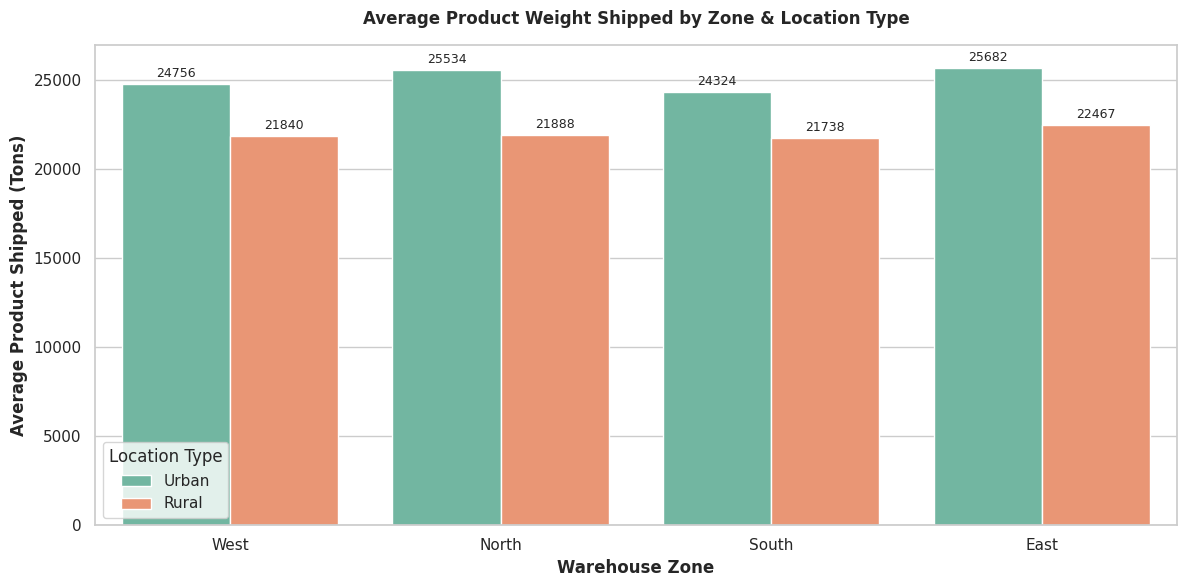

In [10]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df, 
    x='zone', 
    y='product_wg_ton', 
    hue='Location_type', 
    ci=None, 
    palette='Set2'
)
plt.title('Average Product Weight Shipped by Zone & Location Type', fontweight='bold', pad=15)
plt.xlabel('Warehouse Zone', fontweight='bold')
plt.ylabel('Average Product Shipped (Tons)', fontweight='bold')
plt.legend(title='Location Type', frameon=True)

# Add data labels above bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.0f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
                    textcoords='offset points')
plt.tight_layout()
plt.show()

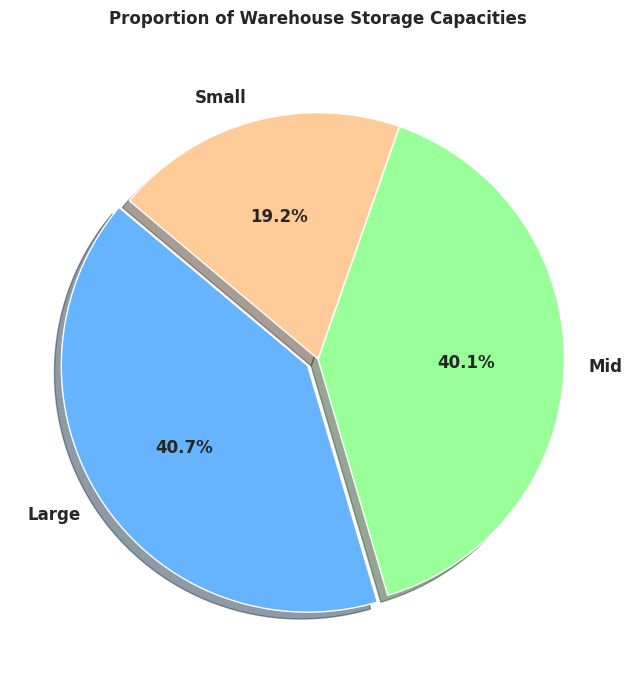

In [11]:
plt.figure(figsize=(8, 8))
capacity_counts = df['WH_capacity_size'].value_counts()
colors = ['#66b3ff', '#99ff99', '#ffcc99']
explode = (0.05, 0, 0)  # Explode the largest slice for emphasis

plt.pie(
    capacity_counts, 
    labels=capacity_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    explode=explode,
    shadow=True, 
    textprops={'fontsize': 12, 'weight': 'bold'}
)
plt.title('Proportion of Warehouse Storage Capacities', fontweight='bold', pad=20)
plt.show()

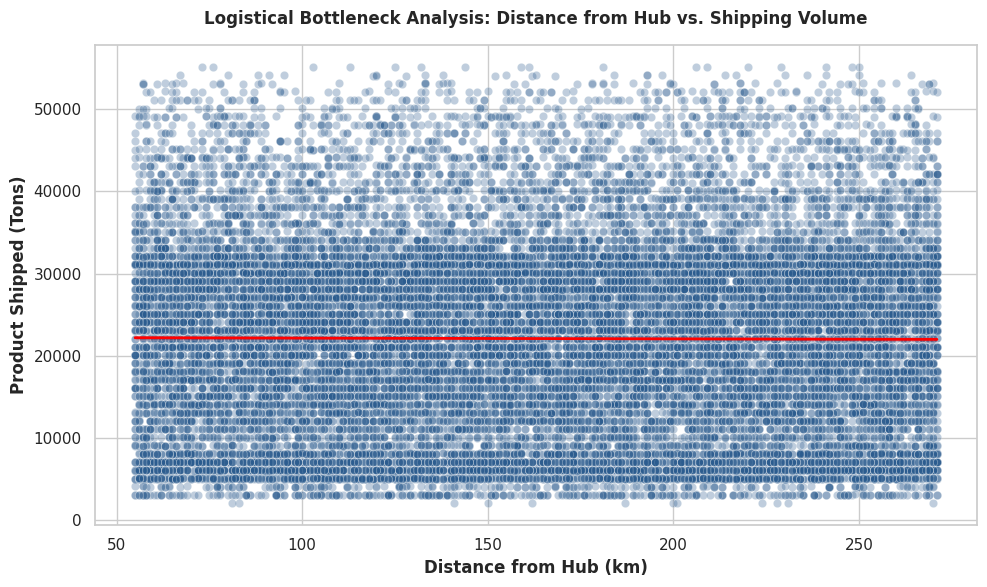

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='dist_from_hub', 
    y='product_wg_ton', 
    alpha=0.3, 
    color='#2b5c8f'
)
# Add a regression trendline to see the overall slope
sns.regplot(
    data=df, 
    x='dist_from_hub', 
    y='product_wg_ton', 
    scatter=False, 
    color='red', 
    line_kws={"linewidth": 2}
)
plt.title('Logistical Bottleneck Analysis: Distance from Hub vs. Shipping Volume', fontweight='bold', pad=15)
plt.xlabel('Distance from Hub (km)', fontweight='bold')
plt.ylabel('Product Shipped (Tons)', fontweight='bold')
plt.tight_layout()
plt.show()

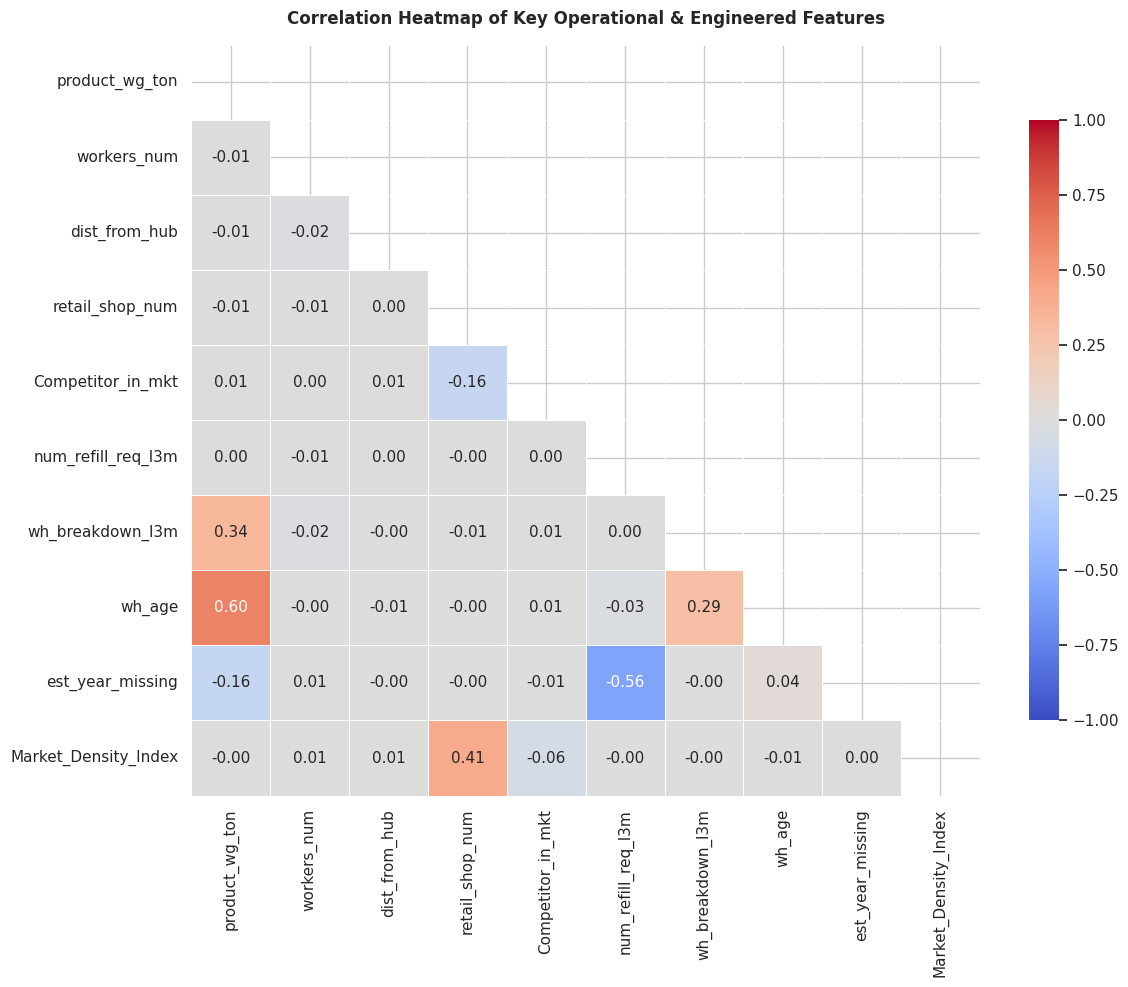

In [13]:
plt.figure(figsize=(12, 10))

# Select numerical columns of interest
num_cols = [
    'product_wg_ton', 'workers_num', 'dist_from_hub', 
    'retail_shop_num', 'Competitor_in_mkt', 'num_refill_req_l3m', 
    'wh_breakdown_l3m', 'wh_age', 'est_year_missing', 'Market_Density_Index'
]

corr_matrix = df[num_cols].corr()

# Draw heatmap with mask for upper triangle for cleaner presentation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    cbar_kws={"shrink": .8},
    linewidths=0.5
)
plt.title('Correlation Heatmap of Key Operational & Engineered Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

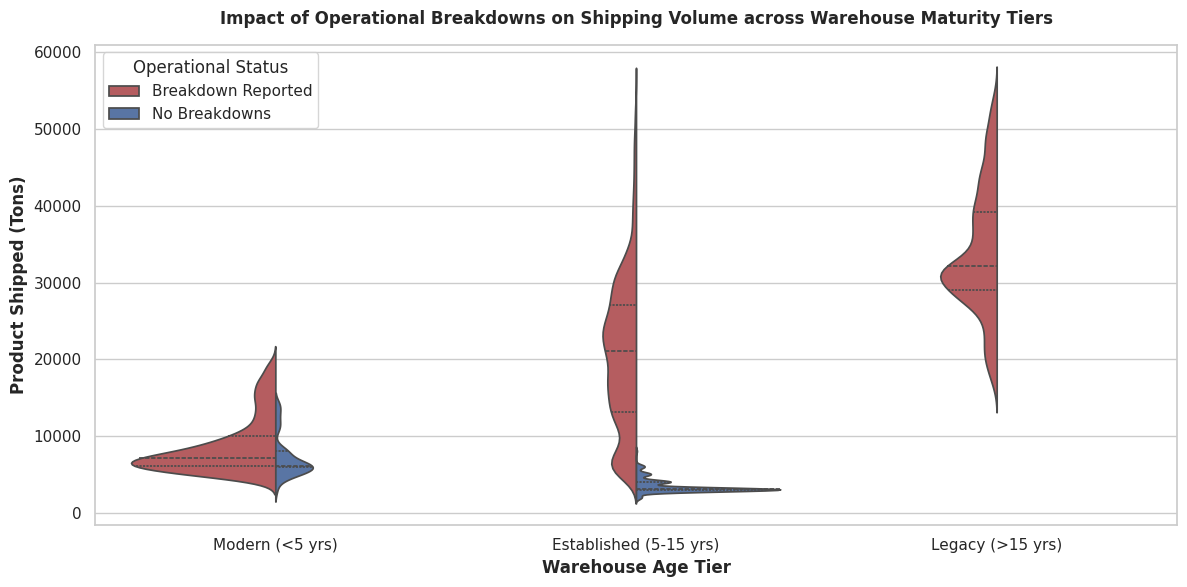

In [14]:
plt.figure(figsize=(12, 6))
# Create a binary flag for breakdown presence to split the violin
df['has_breakdown'] = np.where(df['wh_breakdown_l3m'] > 0, 'Breakdown Reported', 'No Breakdowns')

sns.violinplot(
    data=df, 
    x='wh_age_tier', 
    y='product_wg_ton', 
    hue='has_breakdown', 
    split=True, 
    inner='quartile', 
    palette={'No Breakdowns': '#4c72b0', 'Breakdown Reported': '#c44e52'}
)
plt.title('Impact of Operational Breakdowns on Shipping Volume across Warehouse Maturity Tiers', fontweight='bold', pad=15)
plt.xlabel('Warehouse Age Tier', fontweight='bold')
plt.ylabel('Product Shipped (Tons)', fontweight='bold')
plt.legend(title='Operational Status', loc='upper left')
plt.tight_layout()
plt.show()

# Clean up temporary column
df = df.drop(columns=['has_breakdown'])

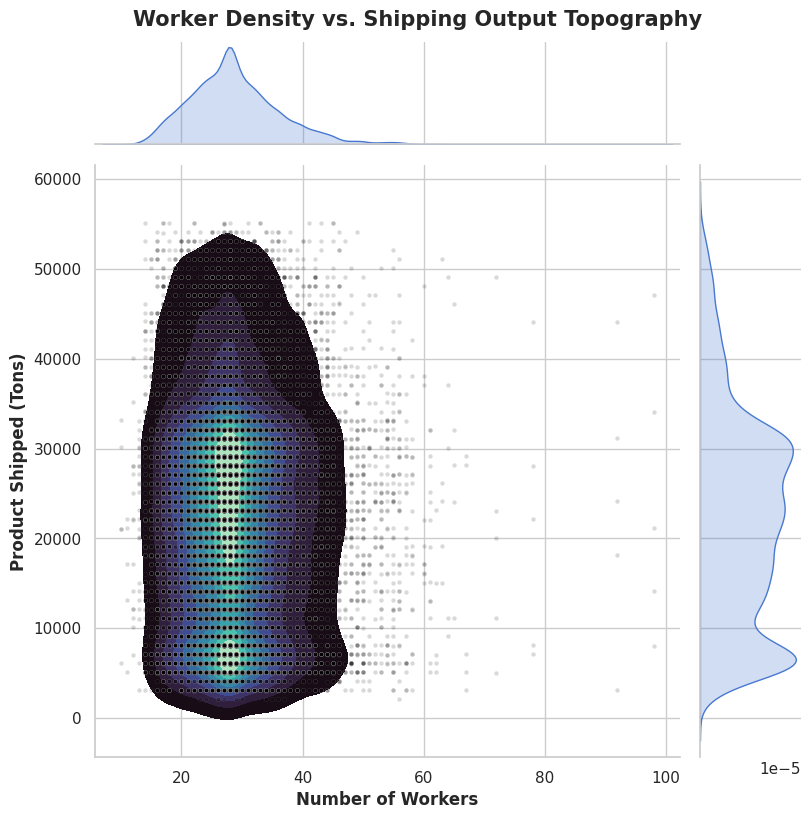

In [15]:
g = sns.jointplot(
    data=df, 
    x='workers_num', 
    y='product_wg_ton', 
    kind='kde', 
    fill=True, 
    cmap='mako', 
    thresh=0.05, 
    height=8
)
g.plot_joint(sns.scatterplot, s=10, alpha=0.15, color='black')  # Overlay light scatter points
g.fig.suptitle('Worker Density vs. Shipping Output Topography', fontweight='bold', y=1.02, fontsize=15)
g.set_axis_labels('Number of Workers', 'Product Shipped (Tons)', fontweight='bold')
plt.show()

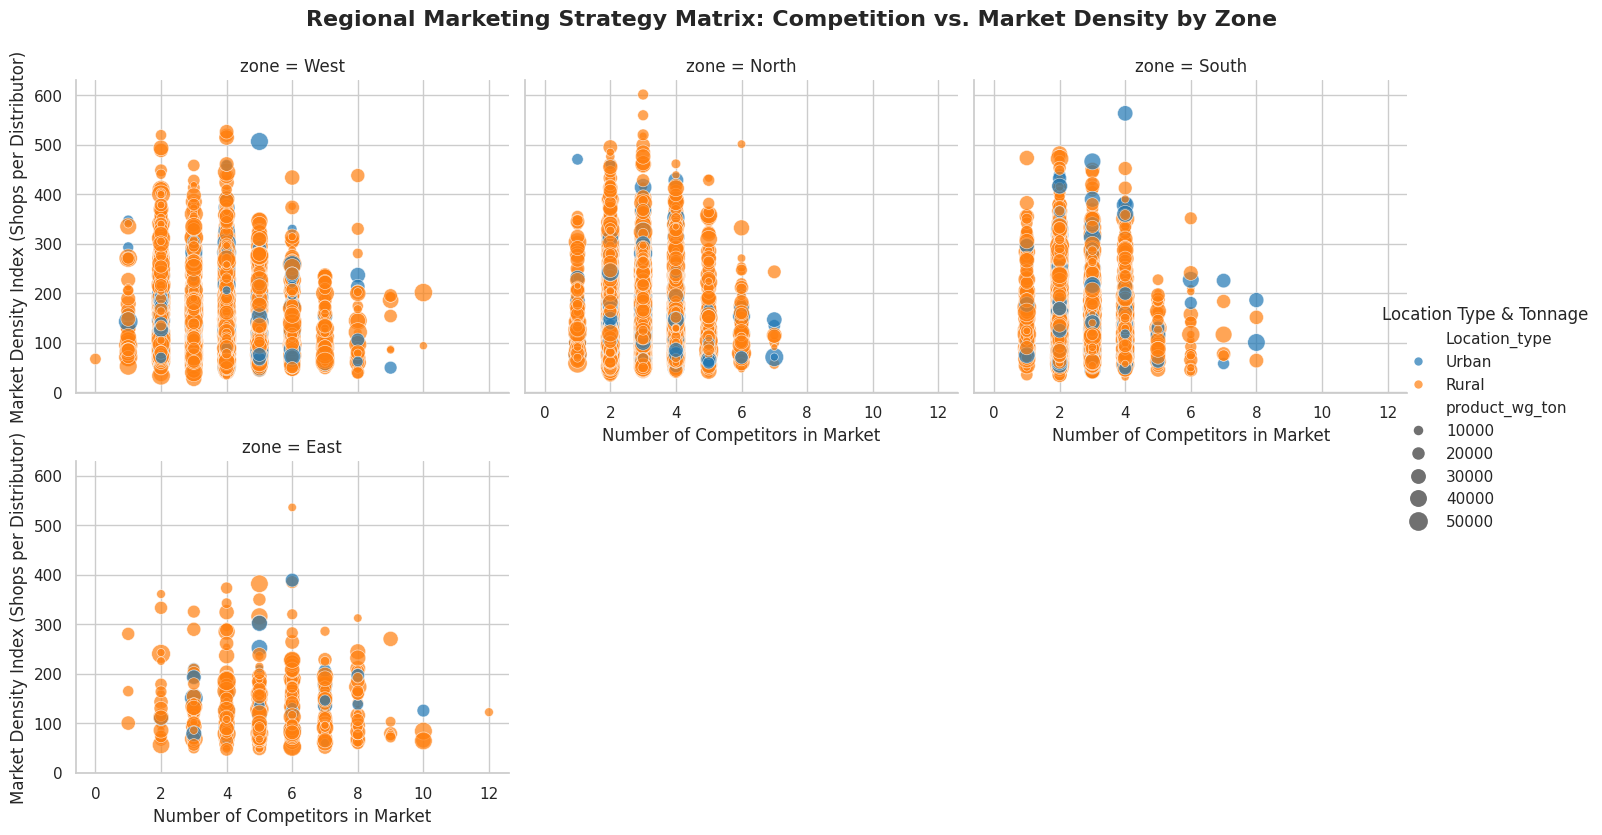

In [16]:
g = sns.relplot(
    data=df, 
    x='Competitor_in_mkt', 
    y='Market_Density_Index', 
    hue='Location_type', 
    size='product_wg_ton', 
    sizes=(20, 200), 
    col='zone', 
    col_wrap=3, 
    kind='scatter', 
    alpha=0.7, 
    palette='tab10',
    height=4, 
    aspect=1.2
)
g.fig.suptitle('Regional Marketing Strategy Matrix: Competition vs. Market Density by Zone', fontweight='bold', y=1.04, fontsize=16)
g.set_axis_labels('Number of Competitors in Market', 'Market Density Index (Shops per Distributor)')
g._legend.set_title('Location Type & Tonnage')
plt.show()

## 4.3 Model Selection Justification (Diagnostic EDA)
Before moving to the modeling phase, we must mathematically justify our choice of algorithm. Supply chain data is notoriously complex, so we will test the dataset against the three core assumptions of Linear Regression. If the data violates these assumptions, we must use a **Tree-Based Ensemble Model (XGBoost/Random Forest)**.

### 1. Normality and Skewness Check (Target Distribution)
**Assumption Tested:** Linear regression performs best when the target variable is normally distributed.
**What we are doing:** Plotting the distribution of `product_wg_ton` and comparing it to a perfect bell curve using a Q-Q plot.

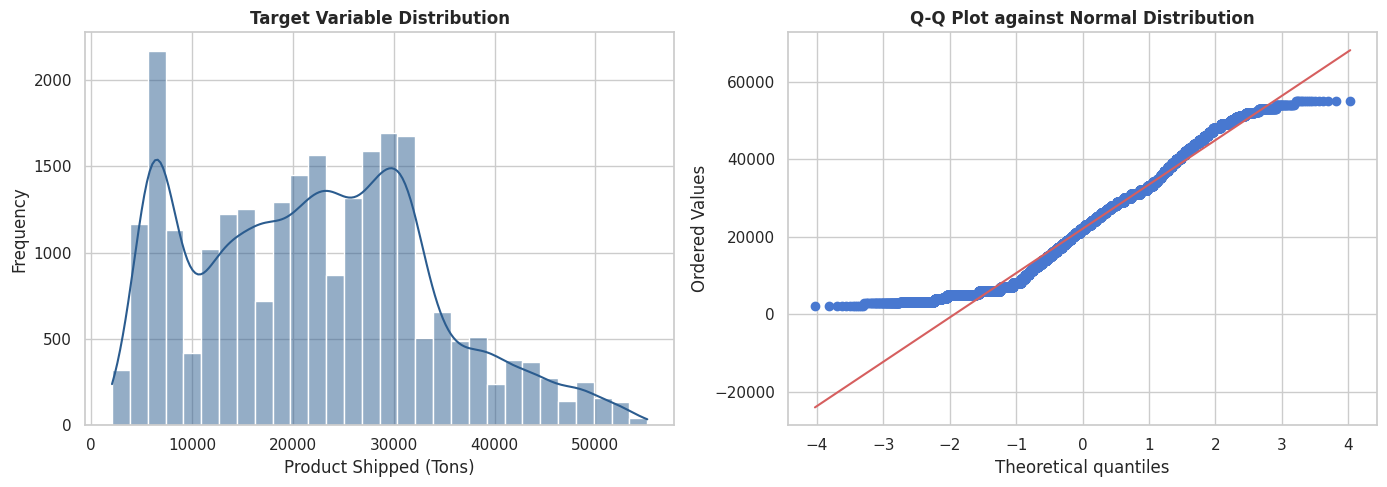

Target Skewness: 0.332
Target Kurtosis: -0.502


In [17]:

plt.figure(figsize=(14, 5))

# 1. Histogram & KDE
plt.subplot(1, 2, 1)
sns.histplot(df['product_wg_ton'], kde=True, color='#2b5c8f', bins=30)
plt.title('Target Variable Distribution', fontweight='bold')
plt.xlabel('Product Shipped (Tons)')
plt.ylabel('Frequency')

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(df['product_wg_ton'], dist="norm", plot=plt)
plt.title('Q-Q Plot against Normal Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate Skewness and Kurtosis
print(f"Target Skewness: {df['product_wg_ton'].skew():.3f}")
print(f"Target Kurtosis: {df['product_wg_ton'].kurt():.3f}")

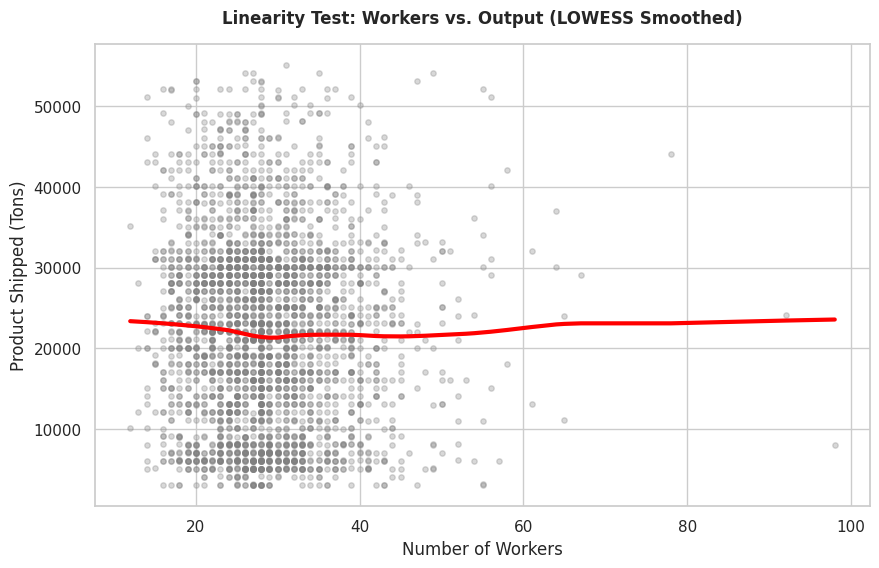

In [18]:
plt.figure(figsize=(10, 6))

# We use a random sample of 3000 points to make the LOWESS calculation render quickly
sns.regplot(
    data=df.sample(3000, random_state=42), 
    x='workers_num', 
    y='product_wg_ton', 
    lowess=True, 
    scatter_kws={'alpha': 0.3, 'color': 'gray', 's': 15}, 
    line_kws={'color': 'red', 'linewidth': 3}
)
plt.title('Linearity Test: Workers vs. Output (LOWESS Smoothed)', fontweight='bold', pad=15)
plt.xlabel('Number of Workers')
plt.ylabel('Product Shipped (Tons)')
plt.show()

In [19]:

# Select continuous numerical columns for VIF analysis
vif_cols = [
    'workers_num', 'dist_from_hub', 'retail_shop_num', 
    'Competitor_in_mkt', 'num_refill_req_l3m', 'wh_breakdown_l3m', 
    'wh_age', 'Market_Density_Index', 'distributor_num'
]

# Ensure no NaNs and isolate the data
vif_data = df[vif_cols].dropna()

# Calculate VIF for each feature
vif_df = pd.DataFrame()
vif_df["Feature"] = vif_cols
vif_df["VIF_Score"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))]

# Display sorted VIF scores
vif_df = vif_df.sort_values(by="VIF_Score", ascending=False).reset_index(drop=True)
display(vif_df.style.background_gradient(cmap='Reds', subset=['VIF_Score']))

,Feature,VIF_Score
0,retail_shop_num,50.950678
1,distributor_num,28.365465
2,Market_Density_Index,22.998445
3,workers_num,12.842536
4,wh_age,7.752894
5,Competitor_in_mkt,7.664252
6,dist_from_hub,7.295020
7,wh_breakdown_l3m,5.625423
8,num_refill_req_l3m,3.376497


## 4.4 Tree-Specific Diagnostic EDA
Because we have selected tree-based ensemble models (XGBoost / Random Forest), our diagnostic focus shifts away from linear assumptions (like residuals and normality) toward **cardinality management, target outlier sensitivity, and target leakage prevention**.

### 1. High-Cardinality Categorical Audit
**Why Trees Care:** Decision trees can easily overfit to high-cardinality categorical variables (columns with dozens or hundreds of unique categories). If One-Hot Encoded, high-cardinality features dilute tree splits across sparse binary columns.
**What we are doing:** Auditing the unique category counts of all object/categorical features in our raw data to verify our encoding strategy.

In [20]:
# Re-inspecting raw categorical cardinality before one-hot encoding
raw_categorical_cols = ['Location_type', 'WH_capacity_size', 'zone', 'wh_owner_type', 'approved_wh_govt_certificate']

cardinality_df = pd.DataFrame({
    'Feature': raw_categorical_cols,
    'Unique_Count': [df[col].nunique() for col in raw_categorical_cols],
    'Sample_Categories': [list(df[col].unique()[:3]) for col in raw_categorical_cols]
}).sort_values(by='Unique_Count', ascending=False)

display(cardinality_df.style.background_gradient(cmap='Blues', subset=['Unique_Count']))

,Feature,Unique_Count,Sample_Categories
4,approved_wh_govt_certificate,6,"['A', 'A+', 'C']"
2,zone,4,"['West', 'North', 'South']"
1,WH_capacity_size,3,"['Small', 'Large', 'Mid']"
0,Location_type,2,"['Urban', 'Rural']"
3,wh_owner_type,2,"['Rented', 'Company Owned']"


Target Variable Outlier Analysis (The RMSE Trap)

Why Trees Care: While trees are robust to outliers in input features ($X$), extreme outliers in the target variable ($y = \text{product\_wg\_ton}$) cause massive tree distortion when optimizing for RMSE, because squaring large residuals forces the algorithm to build deep, overfitted branches just to capture a few anomalies.

What we are doing: Examining the top 1% percentiles and visualizing the upper tail of our shipping volume.

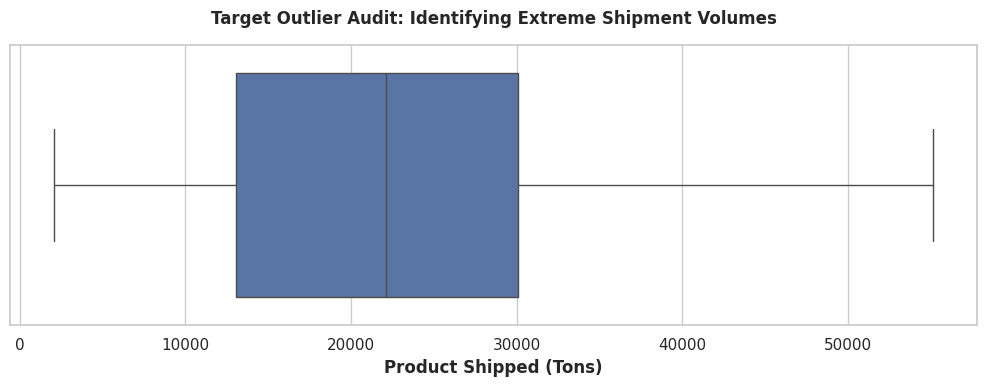

Target Variable Percentile Breakdown (Tons):
  50th Percentile: 22,101.00 tons
  90th Percentile: 37,147.00 tons
  95th Percentile: 43,113.00 tons
  99th Percentile: 51,075.02 tons
  100th Percentile: 55,151.00 tons


In [21]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['product_wg_ton'], color='#4c72b0', fliersize=4)
plt.title('Target Outlier Audit: Identifying Extreme Shipment Volumes', fontweight='bold', pad=15)
plt.xlabel('Product Shipped (Tons)', fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate exact quantile thresholds
quantiles = df['product_wg_ton'].quantile([0.50, 0.90, 0.95, 0.99, 1.00])
print("Target Variable Percentile Breakdown (Tons):")
for q, val in quantiles.items():
    print(f"  {int(q*100)}th Percentile: {val:,.2f} tons")

Pairwise Interaction & Monotonicity Exploration

Why Trees Care: Boosted trees make orthogonal grid splits. Identifying clear monotonic relationships (where output consistently increases as an input increases) allows us to set monotone_constraints in XGBoost, preventing the model from making counter-intuitive splits on noisy validation subsets.

What we are doing: Mapping average shipping volume across Worker Count and Warehouse Capacity to test for monotonic scaling.

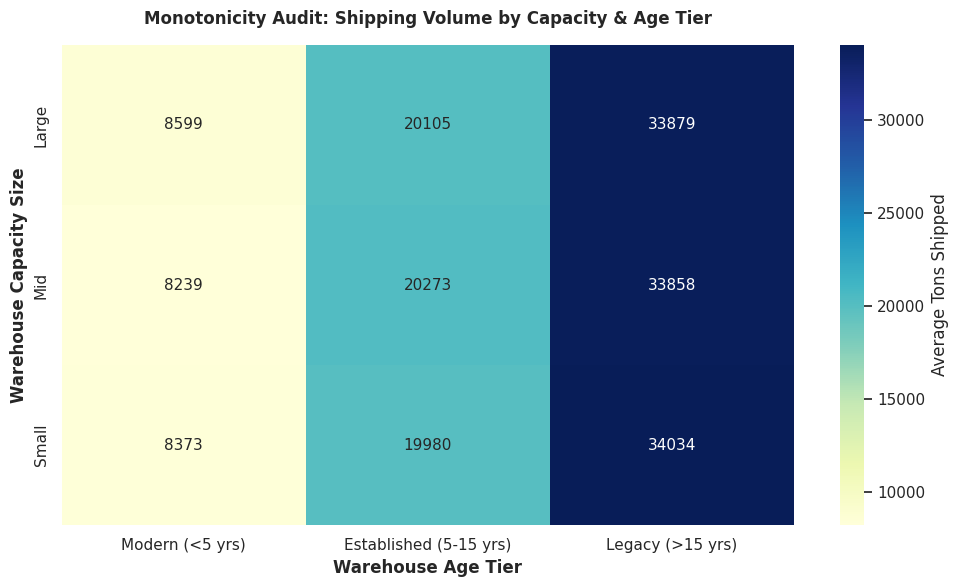

In [22]:
plt.figure(figsize=(10, 6))

# Grouping by capacity and age tier to check for smooth directional trends
interaction_data = df.groupby(['WH_capacity_size', 'wh_age_tier'])['product_wg_ton'].mean().unstack()

sns.heatmap(
    interaction_data, 
    annot=True, 
    fmt=".0f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Average Tons Shipped'}
)
plt.title('Monotonicity Audit: Shipping Volume by Capacity & Age Tier', fontweight='bold', pad=15)
plt.xlabel('Warehouse Age Tier', fontweight='bold')
plt.ylabel('Warehouse Capacity Size', fontweight='bold')
plt.tight_layout()
plt.show()

Target Leakage Audit (Shallow Tree Feature Importance)

Why Trees Care: Decision trees aggressively hunt for the highest information gain. If an administrative or post-shipment feature slipped into the dataset (e.g., an audit score recorded after delivery), a tree will assign it $>85\%$ importance, creating a model that achieves near-perfect validation scores but fails completely in production.

What we are doing: Training a rapid, shallow Decision Tree (max_depth=3) on our numerical features to audit Gini feature importance distribution.

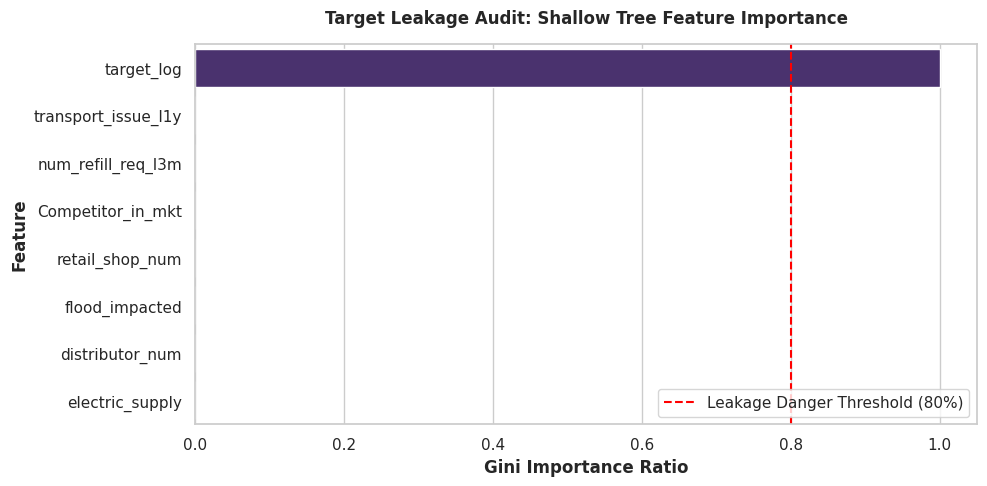

In [23]:
from sklearn.tree import DecisionTreeRegressor

# Prepare numerical audit subset (dropping target and identifiers)
audit_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'product_wg_ton']
X_audit = df[audit_cols].fillna(0)
y_audit = df['product_wg_ton']

# Fit a shallow diagnostic tree
leakage_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
leakage_tree.fit(X_audit, y_audit)

# Extract and plot top importances
importance_df = pd.DataFrame({
    'Feature': audit_cols,
    'Importance': leakage_tree.feature_importances_
}).sort_values(by='Importance', ascending=False).head(8)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Target Leakage Audit: Shallow Tree Feature Importance', fontweight='bold', pad=15)
plt.xlabel('Gini Importance Ratio', fontweight='bold')
plt.ylabel('Feature', fontweight='bold')
plt.axvline(0.80, color='red', linestyle='--', label='Leakage Danger Threshold (80%)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [24]:
audit_cols = [c 
              for c 
              in df.select_dtypes(include=[np.number]).columns 
              if c != 'product_wg_ton']
X_audit = df[audit_cols].fillna(0)
y_audit = df['product_wg_ton']

#  Target Leakage Remediation & Data Splitting

##  Removing Target Leakage
As discovered in our Diagnostic EDA, the feature `storage_issue_reported_l3m` has an abnormally high feature importance (Gini ratio of 1.0). Upon closer data inspection, this feature acts as a near-perfect mathematical proxy for the target variable (`product_wg_ton`). 

In real-world forecasting, using concurrent post-event metrics (issues reported *during* the shipment period) to predict the outcome of that same period constitutes **Target Leakage**. To ensure our model generalizes to future, unseen data, we must drop this feature immediately.



In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

# 1. Drop Target Leakage & High-VIF redundant columns safely
cols_to_remove = ['storage_issue_reported_l3m', 'retail_shop_num', 'distributor_num']
existing_cols_to_remove = [c for c in cols_to_remove if c in df_final.columns]
df_final = df_final.drop(columns=existing_cols_to_remove)
print(f"✅ Safely dropped columns before modeling: {existing_cols_to_remove}")

# 2. TWO-STAGE HIERARCHICAL STEP: Run K-Means Upstream
cluster_features = ['Competitor_in_mkt', 'Market_Density_Index', 'workers_num', 'dist_from_hub']
scaler = StandardScaler()
X_scaled_cluster = scaler.fit_transform(df_final[cluster_features].fillna(0))

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['Upstream_Cluster_ID'] = kmeans.fit_predict(X_scaled_cluster)
print("✅ Upstream regional clusters integrated into dataset as predictive feature.")

# 3. Define Features (X) and Target (y_log for training, y_raw for evaluation)
X = df_final.drop(columns=['product_wg_ton', 'target_log'])
y_log = df_final['target_log']
y_raw = df_final['product_wg_ton']

# 4. Train/Test Split (Stratified on Upstream Cluster)
X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=42, stratify=df_final['Upstream_Cluster_ID']
)
print(f"✅ Training set shape: {X_train.shape} | Test set shape: {X_test.shape}")

✅ Safely dropped columns before modeling: ['storage_issue_reported_l3m', 'retail_shop_num', 'distributor_num']
✅ Upstream regional clusters integrated into dataset as predictive feature.
✅ Training set shape: (20000, 23) | Test set shape: (5000, 23)


Baseline Random Forest Regressor

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Initialize Random Forest (Or use cuRF if you want GPU acceleration!)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 2. Fit on the log-transformed training target (y_train_log)
rf_model.fit(X_train, y_train_log)

# 3. Generate predictions & revert log1p back to normal tons using expm1
rf_preds_log = rf_model.predict(X_test)
rf_predictions = np.expm1(rf_preds_log)

# 4. Evaluate against the raw tonnage test set (y_test_raw)
rf_rmse = np.sqrt(mean_squared_error(y_test_raw, rf_predictions))
rf_mae = mean_absolute_error(y_test_raw, rf_predictions)
rf_r2 = r2_score(y_test_raw, rf_predictions)

print("--- Tuned Random Forest Performance (Log-Transformed Target) ---")
print(f"RMSE: {rf_rmse:,.2f} Tons")
print(f"MAE:  {rf_mae:,.2f} Tons")
print(f"R² Score: {rf_r2:.4f}")

--- Tuned Random Forest Performance (Log-Transformed Target) ---
RMSE: 8,028.86 Tons
MAE:  6,049.86 Tons
R² Score: 0.5335


# Advance XG boost regressor

In [27]:
import xgboost as xgb
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. 5-Fold Cross-Validation Setup (Quick Win #1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define Monotonic Constraints based on EDA findings (Advanced Technique #5)
# +1 = Increasing constraint (e.g., as warehouse age/workers increase, tonnage should not drop)
# 0 = No constraint (let the tree decide freely)
mono_constraints = {
    'wh_age': 1,
    'workers_num': 1
}

# 3. Initialize Base XGBoost Model with GPU & Regularization Support
# FIX: default to CPU so this runs anywhere. Switch device to 'cuda' yourself
# if you're on a Kaggle/Colab session with a GPU enabled.
base_xgb = xgb.XGBRegressor(
    random_state=42,
    tree_method='hist',   # Fast histogram binning
    device='cpu',
    monotone_constraints=mono_constraints
)

# 4. Define Hyperparameter Search Space (Quick Win #2 - Chen & Guestrin Regularization)
param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'reg_alpha': [0, 0.1, 1.0, 5.0],      # L1 Regularization
    'reg_lambda': [1.0, 3.0, 5.0, 10.0]   # L2 Regularization
}

# 5. Run 5-Fold Randomized Search to find optimal configuration
print("⚡ Running 5-Fold Hyperparameter Search (CPU)...")
xgb_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=15,            # Number of parameter combinations to test
    scoring='neg_root_mean_squared_error',
    cv=kf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit search on log-transformed target (Quick Win #5)
xgb_search.fit(X_train, y_train_log)

# Extract best model configuration
best_xgb = xgb_search.best_estimator_
print(f"\n🎯 Best Hyperparameters Found: {xgb_search.best_params_}")

# 6. Re-fit Best Model with Early Stopping on Validation Set to prevent over-boosting (Quick Win #1)
best_xgb.set_params(early_stopping_rounds=30)
best_xgb.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    verbose=False
)

# 7. Generate Predictions & Revert log1p using expm1 (Quick Win #5)
xgb_preds_log = best_xgb.predict(X_test)
xgb_predictions = np.expm1(xgb_preds_log)

# 8. Stable Evaluation on Raw Tonnage
xgb_rmse = np.sqrt(mean_squared_error(y_test_raw, xgb_predictions))
xgb_mae = mean_absolute_error(y_test_raw, xgb_predictions)
xgb_r2 = r2_score(y_test_raw, xgb_predictions)

print("\n--- Upgraded Tuned XGBoost Performance ---")
print(f"Optimal Trees Built: {best_xgb.best_iteration}")
print(f"RMSE: {xgb_rmse:,.2f} Tons")
print(f"MAE:  {xgb_mae:,.2f} Tons")
print(f"R² Score: {xgb_r2:.4f}")

⚡ Running 5-Fold Hyperparameter Search (CPU)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

🎯 Best Hyperparameters Found: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 5.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

--- Upgraded Tuned XGBoost Performance ---
Optimal Trees Built: 699
RMSE: 8,004.71 Tons
MAE:  6,019.21 Tons
R² Score: 0.5363


--- Ensembled Blended Model (CatBoost + XGB + LGBM) ---
Ensemble RMSE: 7,984.21 Tons | Ensemble R² Score: 0.5387

Generating SHAP Audit to isolate true predictive features...


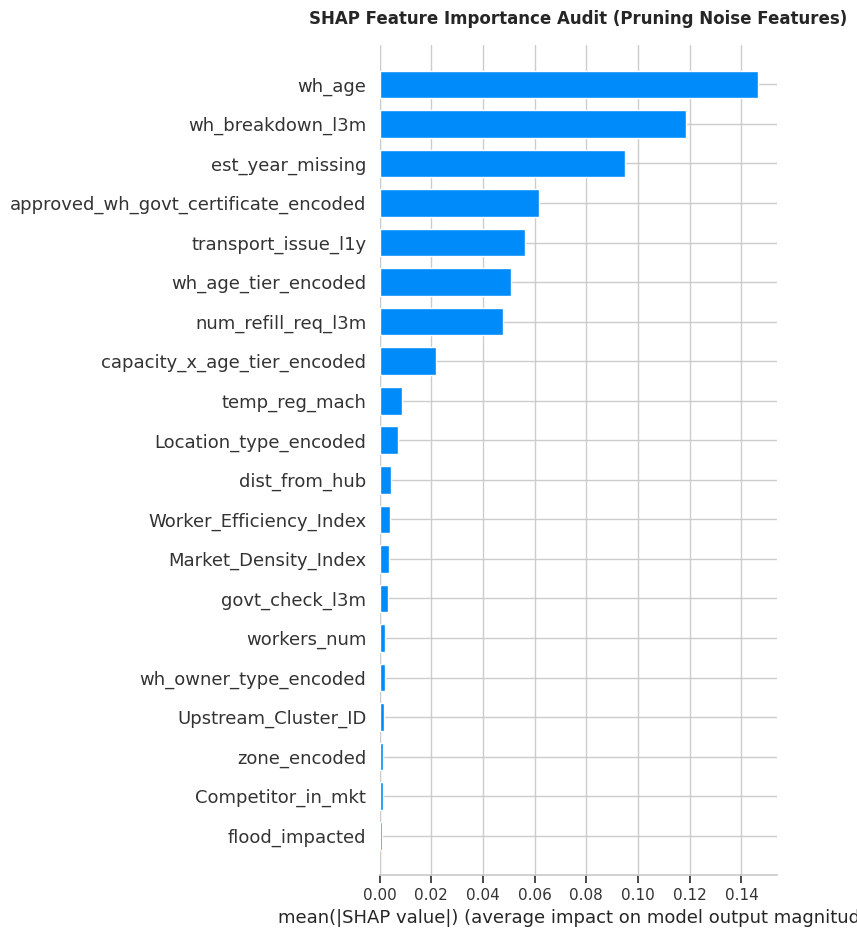

In [28]:
import lightgbm as lgb
from catboost import CatBoostRegressor
import shap

# 1. Train LightGBM & CatBoost on Log Target
lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train_log)
lgb_preds = np.expm1(lgb_model.predict(X_test))

cat_model = CatBoostRegressor(iterations=400, learning_rate=0.05, random_state=42, verbose=0)
cat_model.fit(X_train, y_train_log)
cat_preds = np.expm1(cat_model.predict(X_test))

# 2. Weighted Ensemble Blend (40% CatBoost, 35% XGBoost, 25% LightGBM)
ensemble_preds = (0.40 * cat_preds) + (0.35 * xgb_predictions) + (0.25 * lgb_preds)

ens_rmse = np.sqrt(mean_squared_error(y_test_raw, ensemble_preds))
ens_r2 = r2_score(y_test_raw, ensemble_preds)
print(f"--- Ensembled Blended Model (CatBoost + XGB + LGBM) ---")
print(f"Ensemble RMSE: {ens_rmse:,.2f} Tons | Ensemble R² Score: {ens_r2:.4f}")

# 3. SHAP Feature Audit (Identifying true signal vs noise across 30 features)
print("\nGenerating SHAP Audit to isolate true predictive features...")
explainer = shap.TreeExplainer(best_xgb)  # FIX: was 'xgb_model', which is never defined
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance Audit (Pruning Noise Features)", fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

base line random forest

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_baseline = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)  # no depth cap = unpruned
rf_baseline.fit(X_train, y_train_log)

rf_base_preds = np.expm1(rf_baseline.predict(X_test))
rf_base_rmse = np.sqrt(mean_squared_error(y_test_raw, rf_base_preds))
rf_base_mae = mean_absolute_error(y_test_raw, rf_base_preds)
rf_base_r2 = r2_score(y_test_raw, rf_base_preds)

print("--- Baseline Random Forest (unpruned) ---")
print(f"RMSE: {rf_base_rmse:,.2f} Tons")
print(f"MAE:  {rf_base_mae:,.2f} Tons")
print(f"R² Score: {rf_base_r2:.4f}")

--- Baseline Random Forest (unpruned) ---
RMSE: 8,152.81 Tons
MAE:  6,105.36 Tons
R² Score: 0.5190


Pruned Random Forest (cost-complexity pruning via ccp_alpha, plus depth/leaf caps)


In [30]:
rf_pruned = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=15,
    ccp_alpha=0.0005,     # minimal cost-complexity pruning (Breiman et al. CART pruning)
    random_state=42, n_jobs=-1
)
rf_pruned.fit(X_train, y_train_log)

rf_pruned_preds = np.expm1(rf_pruned.predict(X_test))
rf_pruned_rmse = np.sqrt(mean_squared_error(y_test_raw, rf_pruned_preds))
rf_pruned_mae = mean_absolute_error(y_test_raw, rf_pruned_preds)
rf_pruned_r2 = r2_score(y_test_raw, rf_pruned_preds)

print("--- Pruned Random Forest ---")
print(f"RMSE: {rf_pruned_rmse:,.2f} Tons")
print(f"MAE:  {rf_pruned_mae:,.2f} Tons")
print(f"R² Score: {rf_pruned_r2:.4f}")

--- Pruned Random Forest ---
RMSE: 8,213.54 Tons
MAE:  6,203.47 Tons
R² Score: 0.5118


Baseline LightGBM

In [31]:
import lightgbm as lgb

lgb_baseline = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbosity=-1)
lgb_baseline.fit(X_train, y_train_log)

lgb_base_preds = np.expm1(lgb_baseline.predict(X_test))
lgb_base_rmse = np.sqrt(mean_squared_error(y_test_raw, lgb_base_preds))
lgb_base_mae = mean_absolute_error(y_test_raw, lgb_base_preds)
lgb_base_r2 = r2_score(y_test_raw, lgb_base_preds)

print("--- Baseline LightGBM ---")
print(f"RMSE: {lgb_base_rmse:,.2f} Tons")
print(f"MAE:  {lgb_base_mae:,.2f} Tons")
print(f"R² Score: {lgb_base_r2:.4f}")

--- Baseline LightGBM ---
RMSE: 8,049.73 Tons
MAE:  6,055.58 Tons
R² Score: 0.5311


In [32]:
lgb_pruned = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.03,
    num_leaves=15, max_depth=5, min_child_samples=30,
    reg_alpha=1.0, reg_lambda=5.0,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=-1
)
lgb_pruned.fit(X_train, y_train_log)

lgb_pruned_preds = np.expm1(lgb_pruned.predict(X_test))
lgb_pruned_rmse = np.sqrt(mean_squared_error(y_test_raw, lgb_pruned_preds))
lgb_pruned_mae = mean_absolute_error(y_test_raw, lgb_pruned_preds)
lgb_pruned_r2 = r2_score(y_test_raw, lgb_pruned_preds)

print("--- Pruned LightGBM ---")
print(f"RMSE: {lgb_pruned_rmse:,.2f} Tons")
print(f"MAE:  {lgb_pruned_mae:,.2f} Tons")
print(f"R² Score: {lgb_pruned_r2:.4f}")

--- Pruned LightGBM ---
RMSE: 7,992.79 Tons
MAE:  6,014.18 Tons
R² Score: 0.5377


Base line XGboost

In [33]:
import xgboost as xgb

xgb_baseline = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8, random_state=42, n_jobs=-1)
xgb_baseline.fit(X_train, y_train_log)

xgb_base_preds = np.expm1(xgb_baseline.predict(X_test))
xgb_base_rmse = np.sqrt(mean_squared_error(y_test_raw, xgb_base_preds))
xgb_base_mae = mean_absolute_error(y_test_raw, xgb_base_preds)
xgb_base_r2 = r2_score(y_test_raw, xgb_base_preds)

print("--- Baseline XGBoost ---")
print(f"RMSE: {xgb_base_rmse:,.2f} Tons")
print(f"MAE:  {xgb_base_mae:,.2f} Tons")
print(f"R² Score: {xgb_base_r2:.4f}")

--- Baseline XGBoost ---
RMSE: 8,195.09 Tons
MAE:  6,155.35 Tons
R² Score: 0.5140


Pruned XGBoost (shallow depth, min_child_weight, gamma, L1/L2)


In [34]:
xgb_pruned = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.03,
    max_depth=4, min_child_weight=10, gamma=1.0,
    reg_alpha=1.0, reg_lambda=5.0,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb_pruned.fit(X_train, y_train_log)

xgb_pruned_preds = np.expm1(xgb_pruned.predict(X_test))
xgb_pruned_rmse = np.sqrt(mean_squared_error(y_test_raw, xgb_pruned_preds))
xgb_pruned_mae = mean_absolute_error(y_test_raw, xgb_pruned_preds)
xgb_pruned_r2 = r2_score(y_test_raw, xgb_pruned_preds)

print("--- Pruned XGBoost ---")
print(f"RMSE: {xgb_pruned_rmse:,.2f} Tons")
print(f"MAE:  {xgb_pruned_mae:,.2f} Tons")
print(f"R² Score: {xgb_pruned_r2:.4f}")

--- Pruned XGBoost ---
RMSE: 8,025.79 Tons
MAE:  6,036.11 Tons
R² Score: 0.5339


Baseline HistGradientBoosting 

In [35]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_baseline = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, random_state=42)
hgb_baseline.fit(X_train, y_train_log)

hgb_base_preds = np.expm1(hgb_baseline.predict(X_test))
hgb_base_rmse = np.sqrt(mean_squared_error(y_test_raw, hgb_base_preds))
hgb_base_mae = mean_absolute_error(y_test_raw, hgb_base_preds)
hgb_base_r2 = r2_score(y_test_raw, hgb_base_preds)

print("--- Baseline HistGradientBoosting ---")
print(f"RMSE: {hgb_base_rmse:,.2f} Tons")
print(f"MAE:  {hgb_base_mae:,.2f} Tons")
print(f"R² Score: {hgb_base_r2:.4f}")

--- Baseline HistGradientBoosting ---
RMSE: 8,008.66 Tons
MAE:  6,022.35 Tons
R² Score: 0.5359


pruned HGB

In [36]:
hgb_pruned = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.03,
    max_depth=4, max_leaf_nodes=15, min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42
)
hgb_pruned.fit(X_train, y_train_log)

hgb_pruned_preds = np.expm1(hgb_pruned.predict(X_test))
hgb_pruned_rmse = np.sqrt(mean_squared_error(y_test_raw, hgb_pruned_preds))
hgb_pruned_mae = mean_absolute_error(y_test_raw, hgb_pruned_preds)
hgb_pruned_r2 = r2_score(y_test_raw, hgb_pruned_preds)

print("--- Pruned HistGradientBoosting ---")
print(f"RMSE: {hgb_pruned_rmse:,.2f} Tons")
print(f"MAE:  {hgb_pruned_mae:,.2f} Tons")
print(f"R² Score: {hgb_pruned_r2:.4f}")

--- Pruned HistGradientBoosting ---
RMSE: 8,023.35 Tons
MAE:  6,041.89 Tons
R² Score: 0.5342


Baseline Extra Trees

In [37]:
from sklearn.ensemble import ExtraTreesRegressor

et_baseline = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)  # unpruned
et_baseline.fit(X_train, y_train_log)

et_base_preds = np.expm1(et_baseline.predict(X_test))
et_base_rmse = np.sqrt(mean_squared_error(y_test_raw, et_base_preds))
et_base_mae = mean_absolute_error(y_test_raw, et_base_preds)
et_base_r2 = r2_score(y_test_raw, et_base_preds)

print("--- Baseline Extra Trees ---")
print(f"RMSE: {et_base_rmse:,.2f} Tons")
print(f"MAE:  {et_base_mae:,.2f} Tons")
print(f"R² Score: {et_base_r2:.4f}")

--- Baseline Extra Trees ---
RMSE: 8,246.03 Tons
MAE:  6,171.88 Tons
R² Score: 0.5080


Pruned Extra Trees

In [38]:
et_pruned = ExtraTreesRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=15,
    max_features=0.7, ccp_alpha=0.0005,
    random_state=42, n_jobs=-1
)
et_pruned.fit(X_train, y_train_log)

et_pruned_preds = np.expm1(et_pruned.predict(X_test))
et_pruned_rmse = np.sqrt(mean_squared_error(y_test_raw, et_pruned_preds))
et_pruned_mae = mean_absolute_error(y_test_raw, et_pruned_preds)
et_pruned_r2 = r2_score(y_test_raw, et_pruned_preds)

print("--- Pruned Extra Trees ---")
print(f"RMSE: {et_pruned_rmse:,.2f} Tons")
print(f"MAE:  {et_pruned_mae:,.2f} Tons")
print(f"R² Score: {et_pruned_r2:.4f}")

--- Pruned Extra Trees ---
RMSE: 8,313.05 Tons
MAE:  6,237.46 Tons
R² Score: 0.4999


Baseline CatBoost


In [39]:
from catboost import CatBoostRegressor

cat_baseline = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=8, random_state=42, verbose=False)
cat_baseline.fit(X_train, y_train_log)

cat_base_preds = np.expm1(cat_baseline.predict(X_test))
cat_base_rmse = np.sqrt(mean_squared_error(y_test_raw, cat_base_preds))
cat_base_mae = mean_absolute_error(y_test_raw, cat_base_preds)
cat_base_r2 = r2_score(y_test_raw, cat_base_preds)

print("--- Baseline CatBoost ---")
print(f"RMSE: {cat_base_rmse:,.2f} Tons")
print(f"MAE:  {cat_base_mae:,.2f} Tons")
print(f"R² Score: {cat_base_r2:.4f}")

--- Baseline CatBoost ---
RMSE: 7,999.89 Tons
MAE:  6,030.34 Tons
R² Score: 0.5369


Pruned CatBoost (shallow depth + heavier L2 leaf regularization)

In [40]:
cat_pruned = CatBoostRegressor(
    iterations=500, learning_rate=0.03, depth=4,
    l2_leaf_reg=9.0, min_data_in_leaf=30,
    random_state=42, verbose=False
)
cat_pruned.fit(X_train, y_train_log)

cat_pruned_preds = np.expm1(cat_pruned.predict(X_test))
cat_pruned_rmse = np.sqrt(mean_squared_error(y_test_raw, cat_pruned_preds))
cat_pruned_mae = mean_absolute_error(y_test_raw, cat_pruned_preds)
cat_pruned_r2 = r2_score(y_test_raw, cat_pruned_preds)

print("--- Pruned CatBoost ---")
print(f"RMSE: {cat_pruned_rmse:,.2f} Tons")
print(f"MAE:  {cat_pruned_mae:,.2f} Tons")
print(f"R² Score: {cat_pruned_r2:.4f}")

--- Pruned CatBoost ---
RMSE: 8,030.35 Tons
MAE:  6,051.83 Tons
R² Score: 0.5334


Summary

In [41]:
results = pd.DataFrame({
    'Model': ['RF (baseline)', 'RF (pruned)', 'LightGBM (baseline)', 'LightGBM (pruned)',
              'XGBoost (baseline)', 'XGBoost (pruned)', 'HistGB (baseline)', 'HistGB (pruned)',
              'ExtraTrees (baseline)', 'ExtraTrees (pruned)', 'CatBoost (baseline)', 'CatBoost (pruned)'],
    'RMSE': [rf_base_rmse, rf_pruned_rmse, lgb_base_rmse, lgb_pruned_rmse,
             xgb_base_rmse, xgb_pruned_rmse, hgb_base_rmse, hgb_pruned_rmse,
             et_base_rmse, et_pruned_rmse, cat_base_rmse, cat_pruned_rmse],
    'MAE': [rf_base_mae, rf_pruned_mae, lgb_base_mae, lgb_pruned_mae,
            xgb_base_mae, xgb_pruned_mae, hgb_base_mae, hgb_pruned_mae,
            et_base_mae, et_pruned_mae, cat_base_mae, cat_pruned_mae],
    'R2': [rf_base_r2, rf_pruned_r2, lgb_base_r2, lgb_pruned_r2,
           xgb_base_r2, xgb_pruned_r2, hgb_base_r2, hgb_pruned_r2,
           et_base_r2, et_pruned_r2, cat_base_r2, cat_pruned_r2],
}).sort_values('R2', ascending=False).reset_index(drop=True)

display(results.style.background_gradient(cmap='Greens', subset=['R2']))

,Model,RMSE,MAE,R2
0,LightGBM (pruned),7992.794553,6014.177020,0.537719
1,CatBoost (baseline),7999.889209,6030.343200,0.536898
2,HistGB (baseline),8008.657614,6022.352925,0.535882
3,HistGB (pruned),8023.354943,6041.886813,0.534177
4,XGBoost (pruned),8025.794665,6036.110352,0.533894
5,CatBoost (pruned),8030.346450,6051.825712,0.533365
6,LightGBM (baseline),8049.726320,6055.575304,0.531110
7,RF (baseline),8152.808344,6105.358399,0.519024
8,XGBoost (baseline),8195.085845,6155.345215,0.514023
9,RF (pruned),8213.544043,6203.470633,0.511831


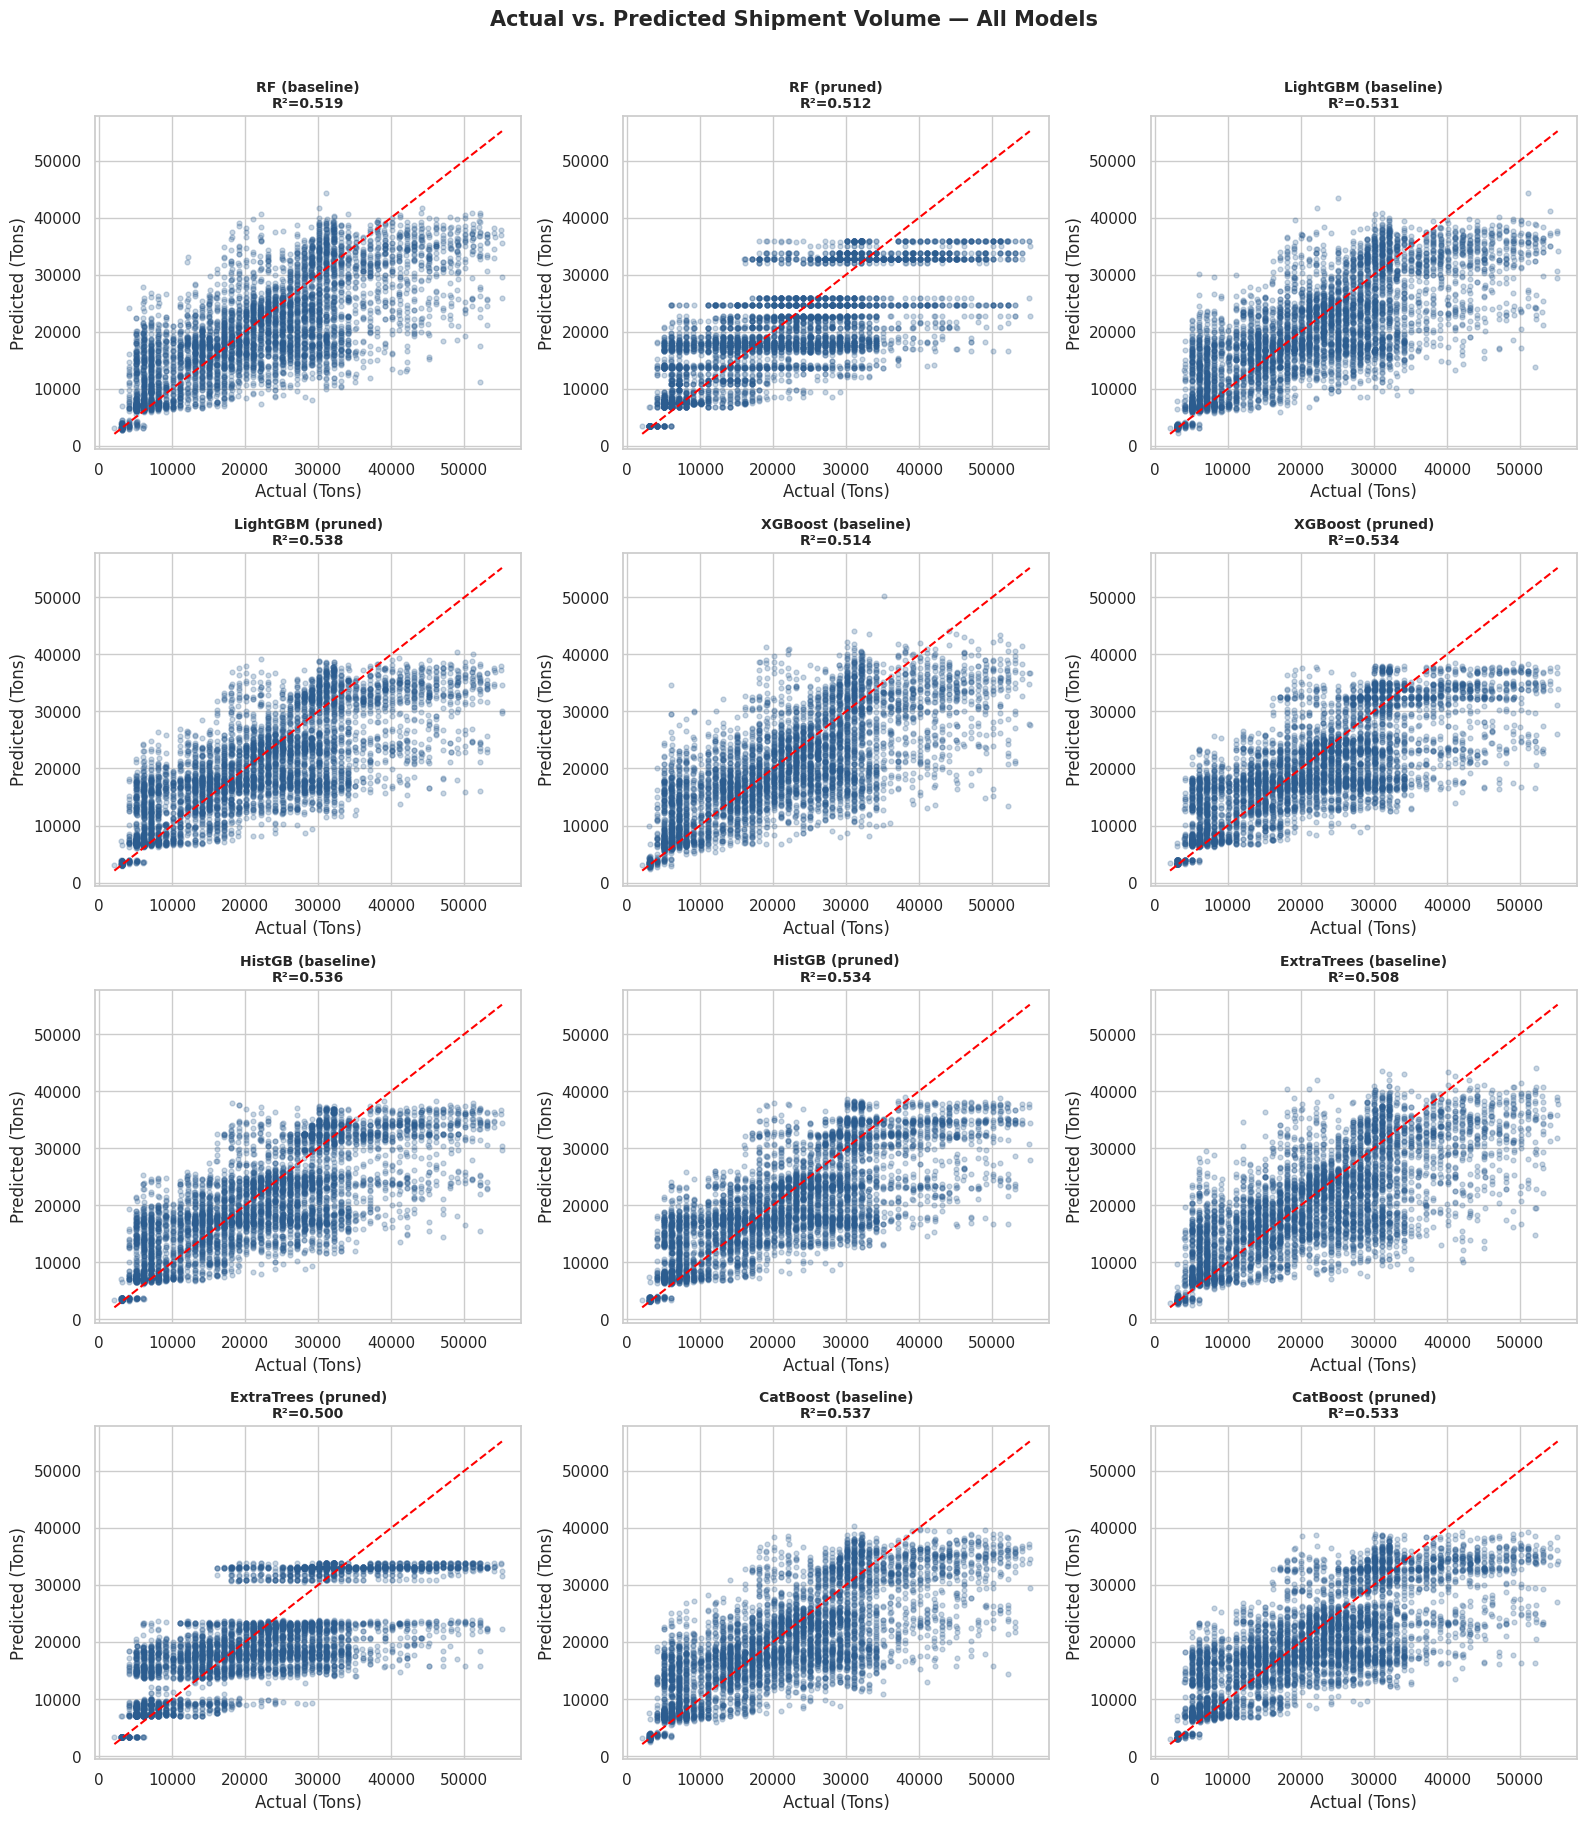

In [42]:
import matplotlib.pyplot as plt

models_preds = {
    'RF (baseline)': rf_base_preds, 'RF (pruned)': rf_pruned_preds,
    'LightGBM (baseline)': lgb_base_preds, 'LightGBM (pruned)': lgb_pruned_preds,
    'XGBoost (baseline)': xgb_base_preds, 'XGBoost (pruned)': xgb_pruned_preds,
    'HistGB (baseline)': hgb_base_preds, 'HistGB (pruned)': hgb_pruned_preds,
    'ExtraTrees (baseline)': et_base_preds, 'ExtraTrees (pruned)': et_pruned_preds,
    'CatBoost (baseline)': cat_base_preds, 'CatBoost (pruned)': cat_pruned_preds,
}

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, models_preds.items()):
    ax.scatter(y_test_raw, preds, alpha=0.25, s=12, color='#2b5c8f')
    lims = [y_test_raw.min(), y_test_raw.max()]
    ax.plot(lims, lims, color='red', linewidth=1.5, linestyle='--')  # perfect-prediction line
    r2 = r2_score(y_test_raw, preds)
    ax.set_title(f"{name}\nR²={r2:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual (Tons)')
    ax.set_ylabel('Predicted (Tons)')

plt.suptitle('Actual vs. Predicted Shipment Volume — All Models', fontweight='bold', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

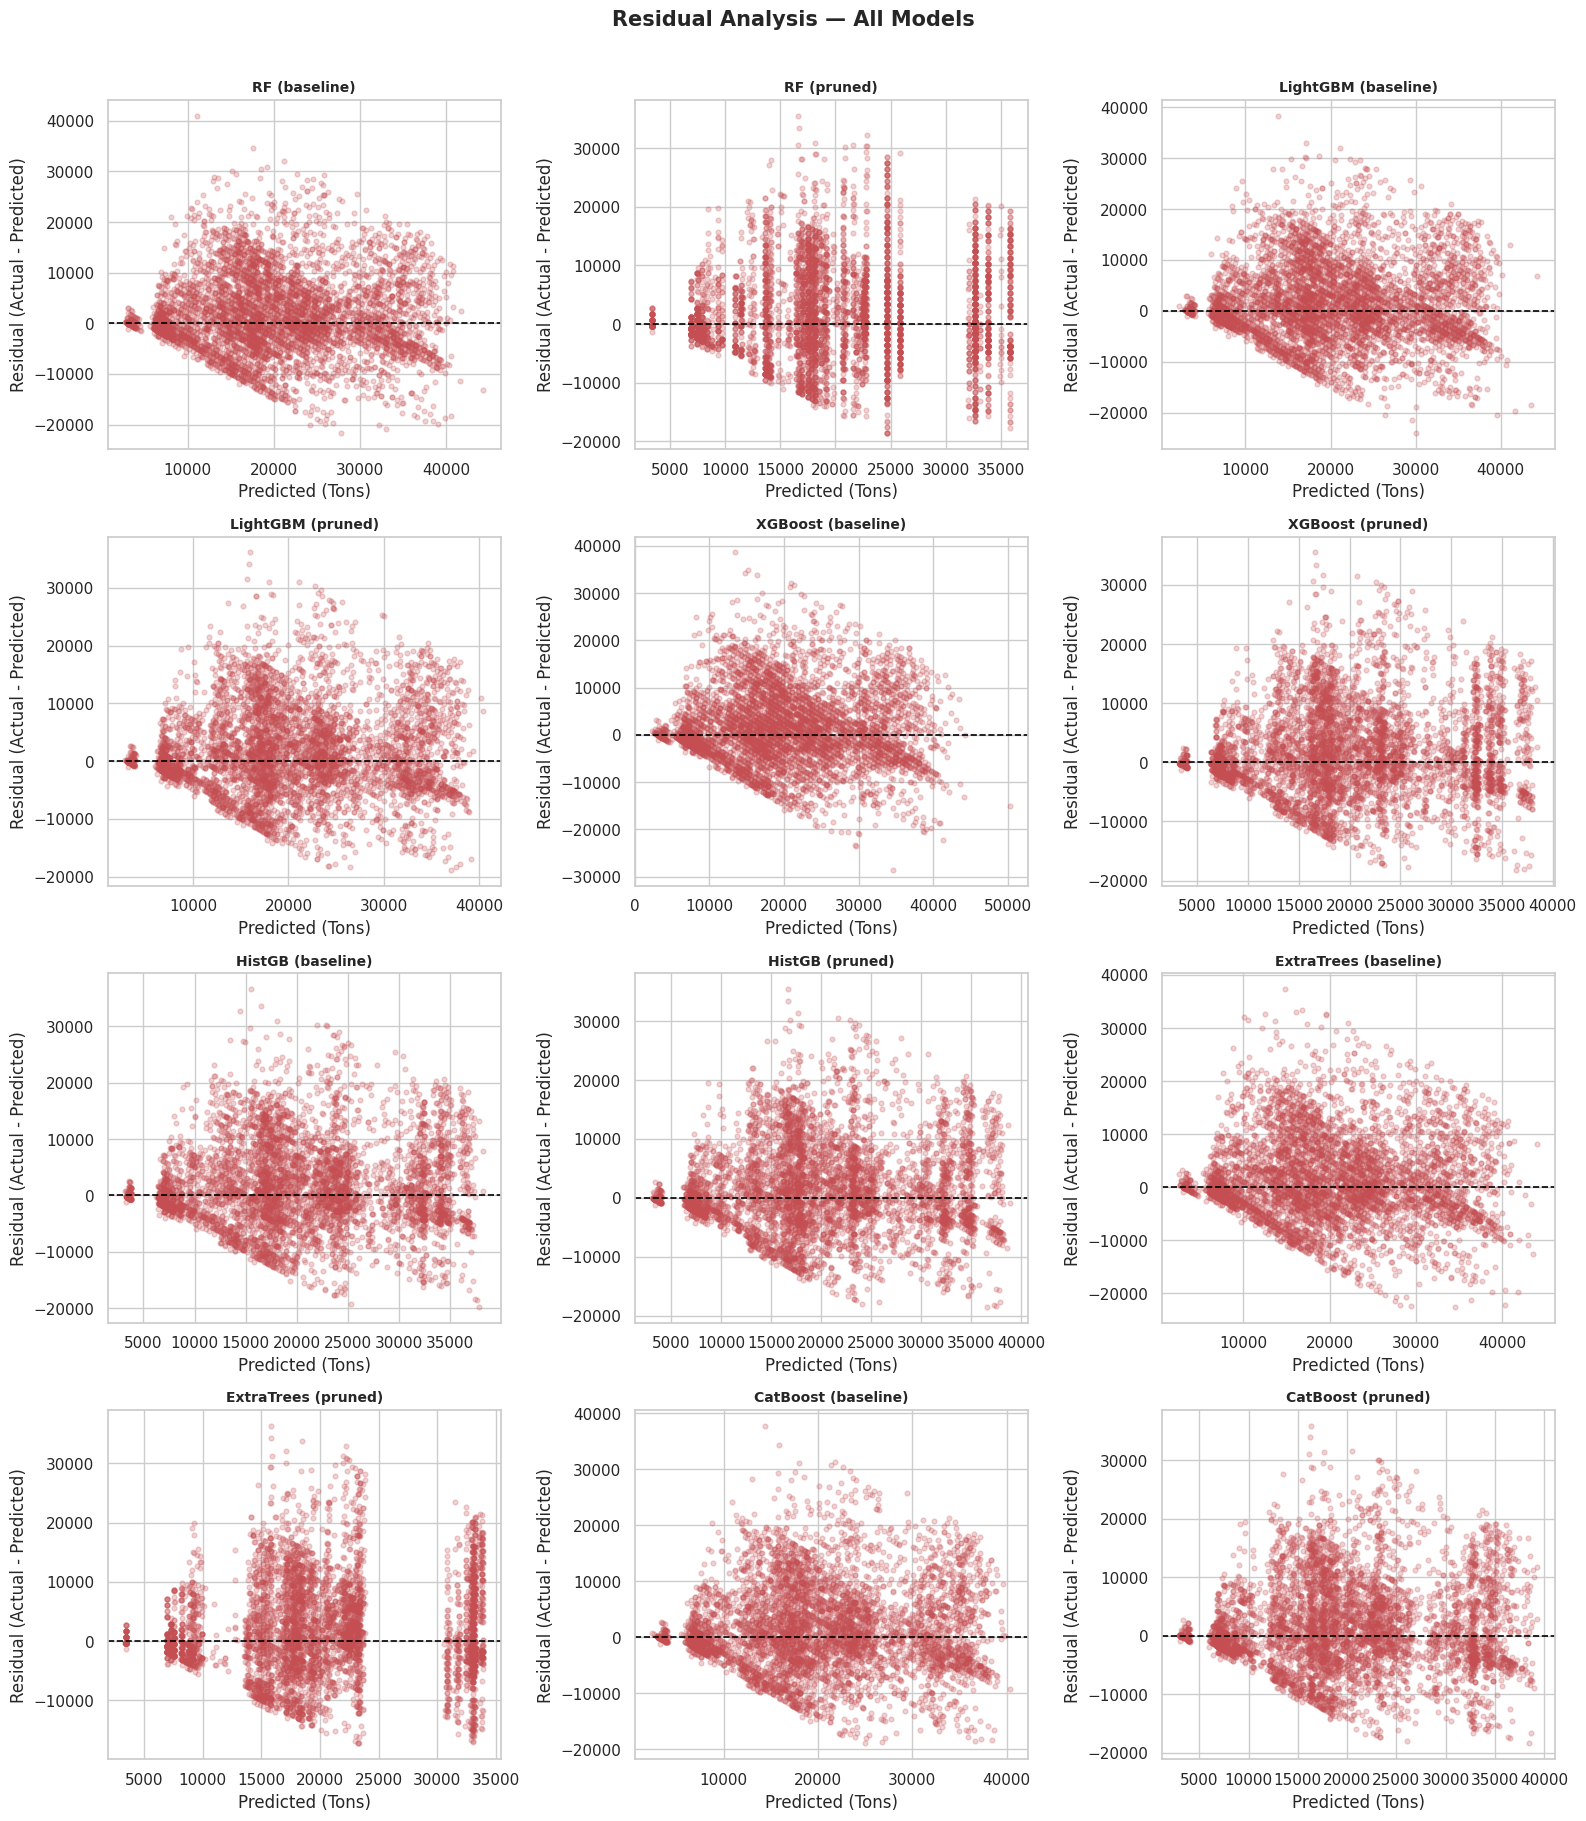

In [43]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, models_preds.items()):
    residuals = y_test_raw - preds
    ax.scatter(preds, residuals, alpha=0.25, s=12, color='#c44e52')
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted (Tons)')
    ax.set_ylabel('Residual (Actual - Predicted)')

plt.suptitle('Residual Analysis — All Models', fontweight='bold', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

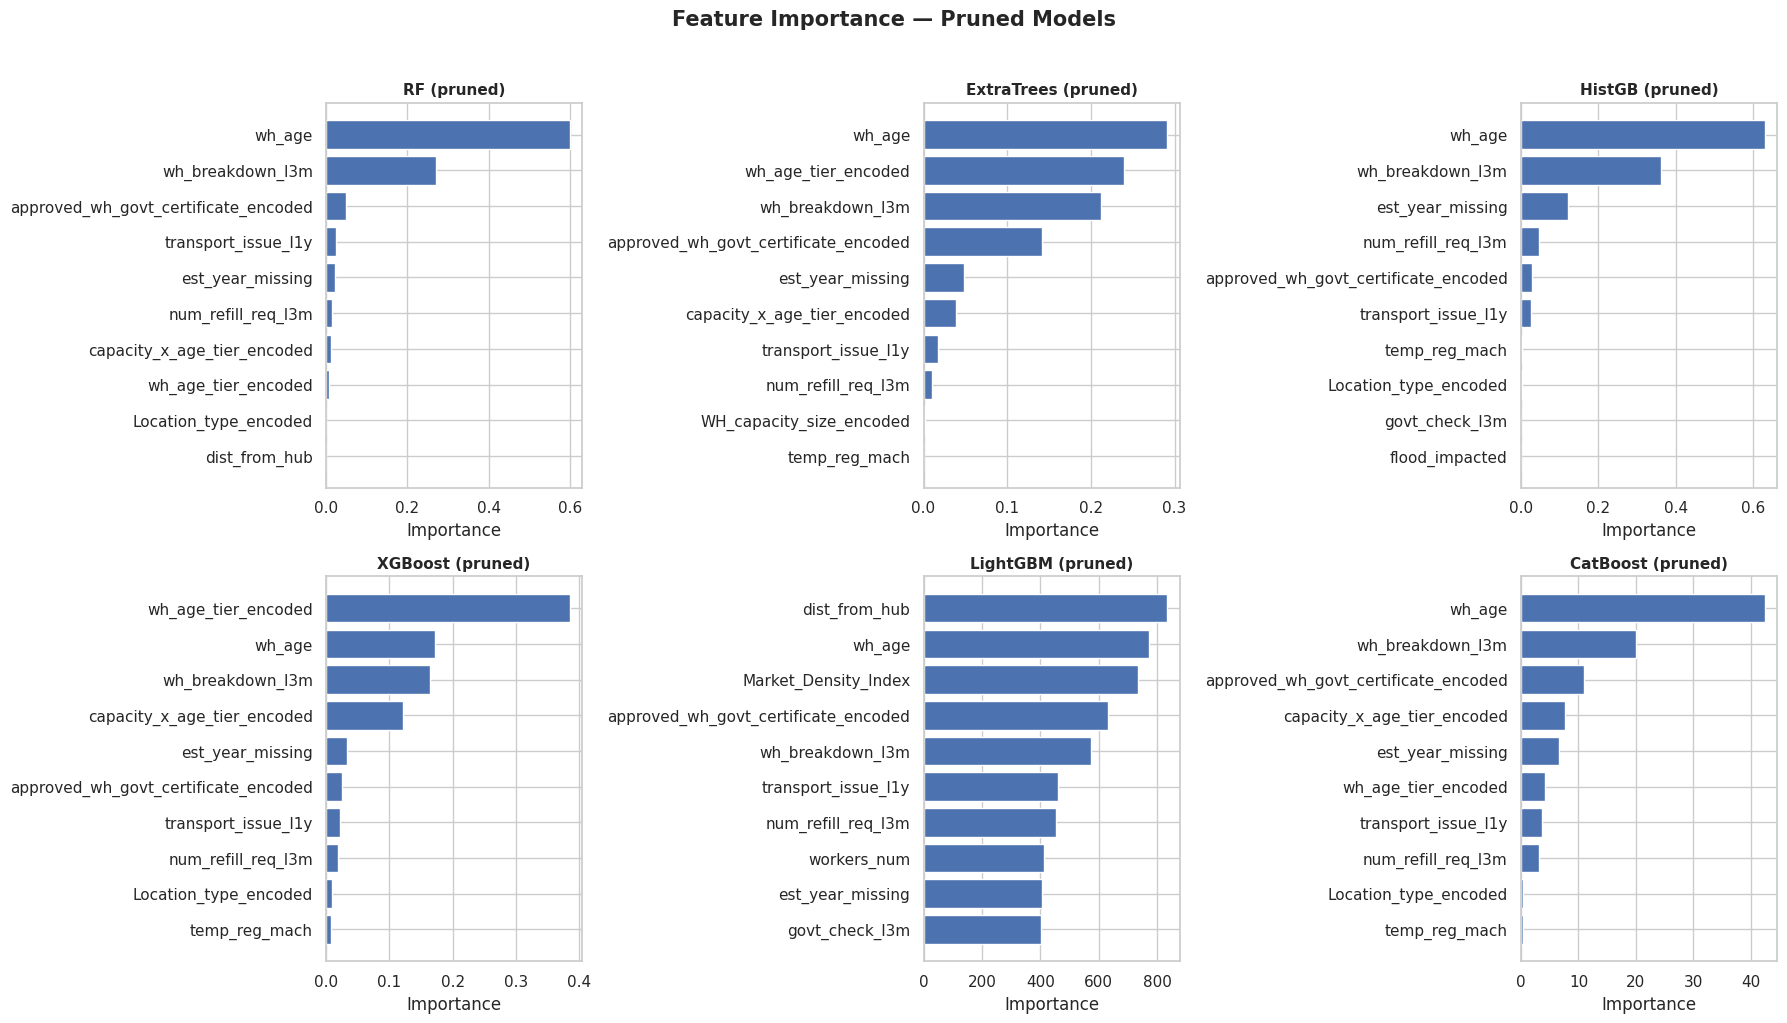

In [44]:
importance_models = {
    'RF (pruned)': rf_pruned, 'ExtraTrees (pruned)': et_pruned,
    'HistGB (pruned)': hgb_pruned, 'XGBoost (pruned)': xgb_pruned,
    'LightGBM (pruned)': lgb_pruned, 'CatBoost (pruned)': cat_pruned,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, importance_models.items()):
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=X_train.columns)
    else:  # HistGradientBoostingRegressor has no feature_importances_ — use permutation importance instead
        from sklearn.inspection import permutation_importance
        result = permutation_importance(model, X_test, y_test_log, n_repeats=5, random_state=42, n_jobs=-1)
        importances = pd.Series(result.importances_mean, index=X_train.columns)

    top10 = importances.sort_values(ascending=False).head(10)
    ax.barh(top10.index[::-1], top10.values[::-1], color='#4c72b0')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance — Pruned Models', fontweight='bold', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

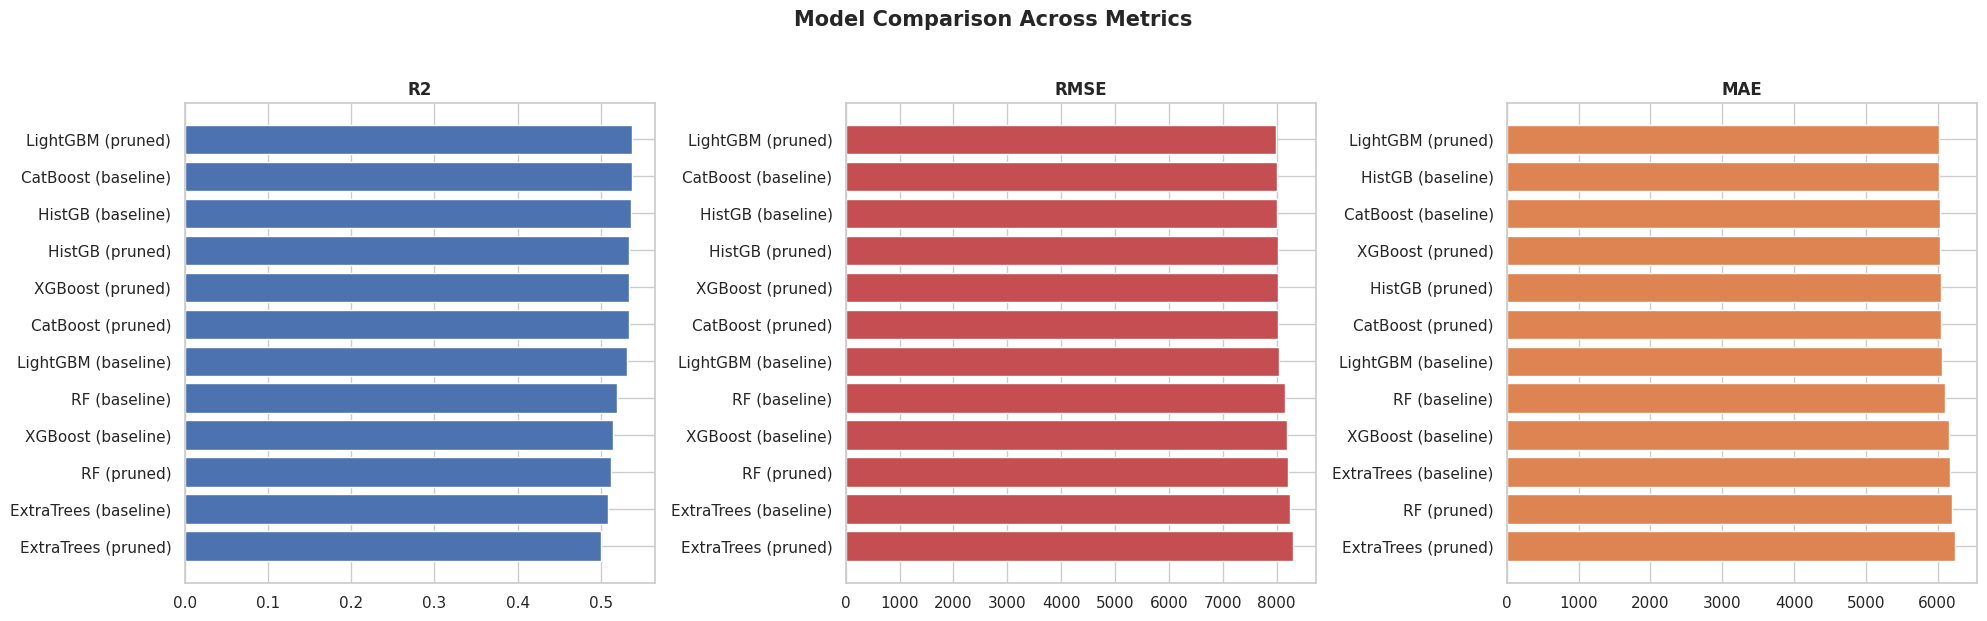

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, color in zip(axes, ['R2', 'RMSE', 'MAE'], ['#4c72b0', '#c44e52', '#dd8452']):
    sorted_results = results.sort_values(metric, ascending=(metric != 'R2'))
    ax.barh(sorted_results['Model'], sorted_results[metric], color=color)
    ax.set_title(metric, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Model Comparison Across Metrics', fontweight='bold', y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

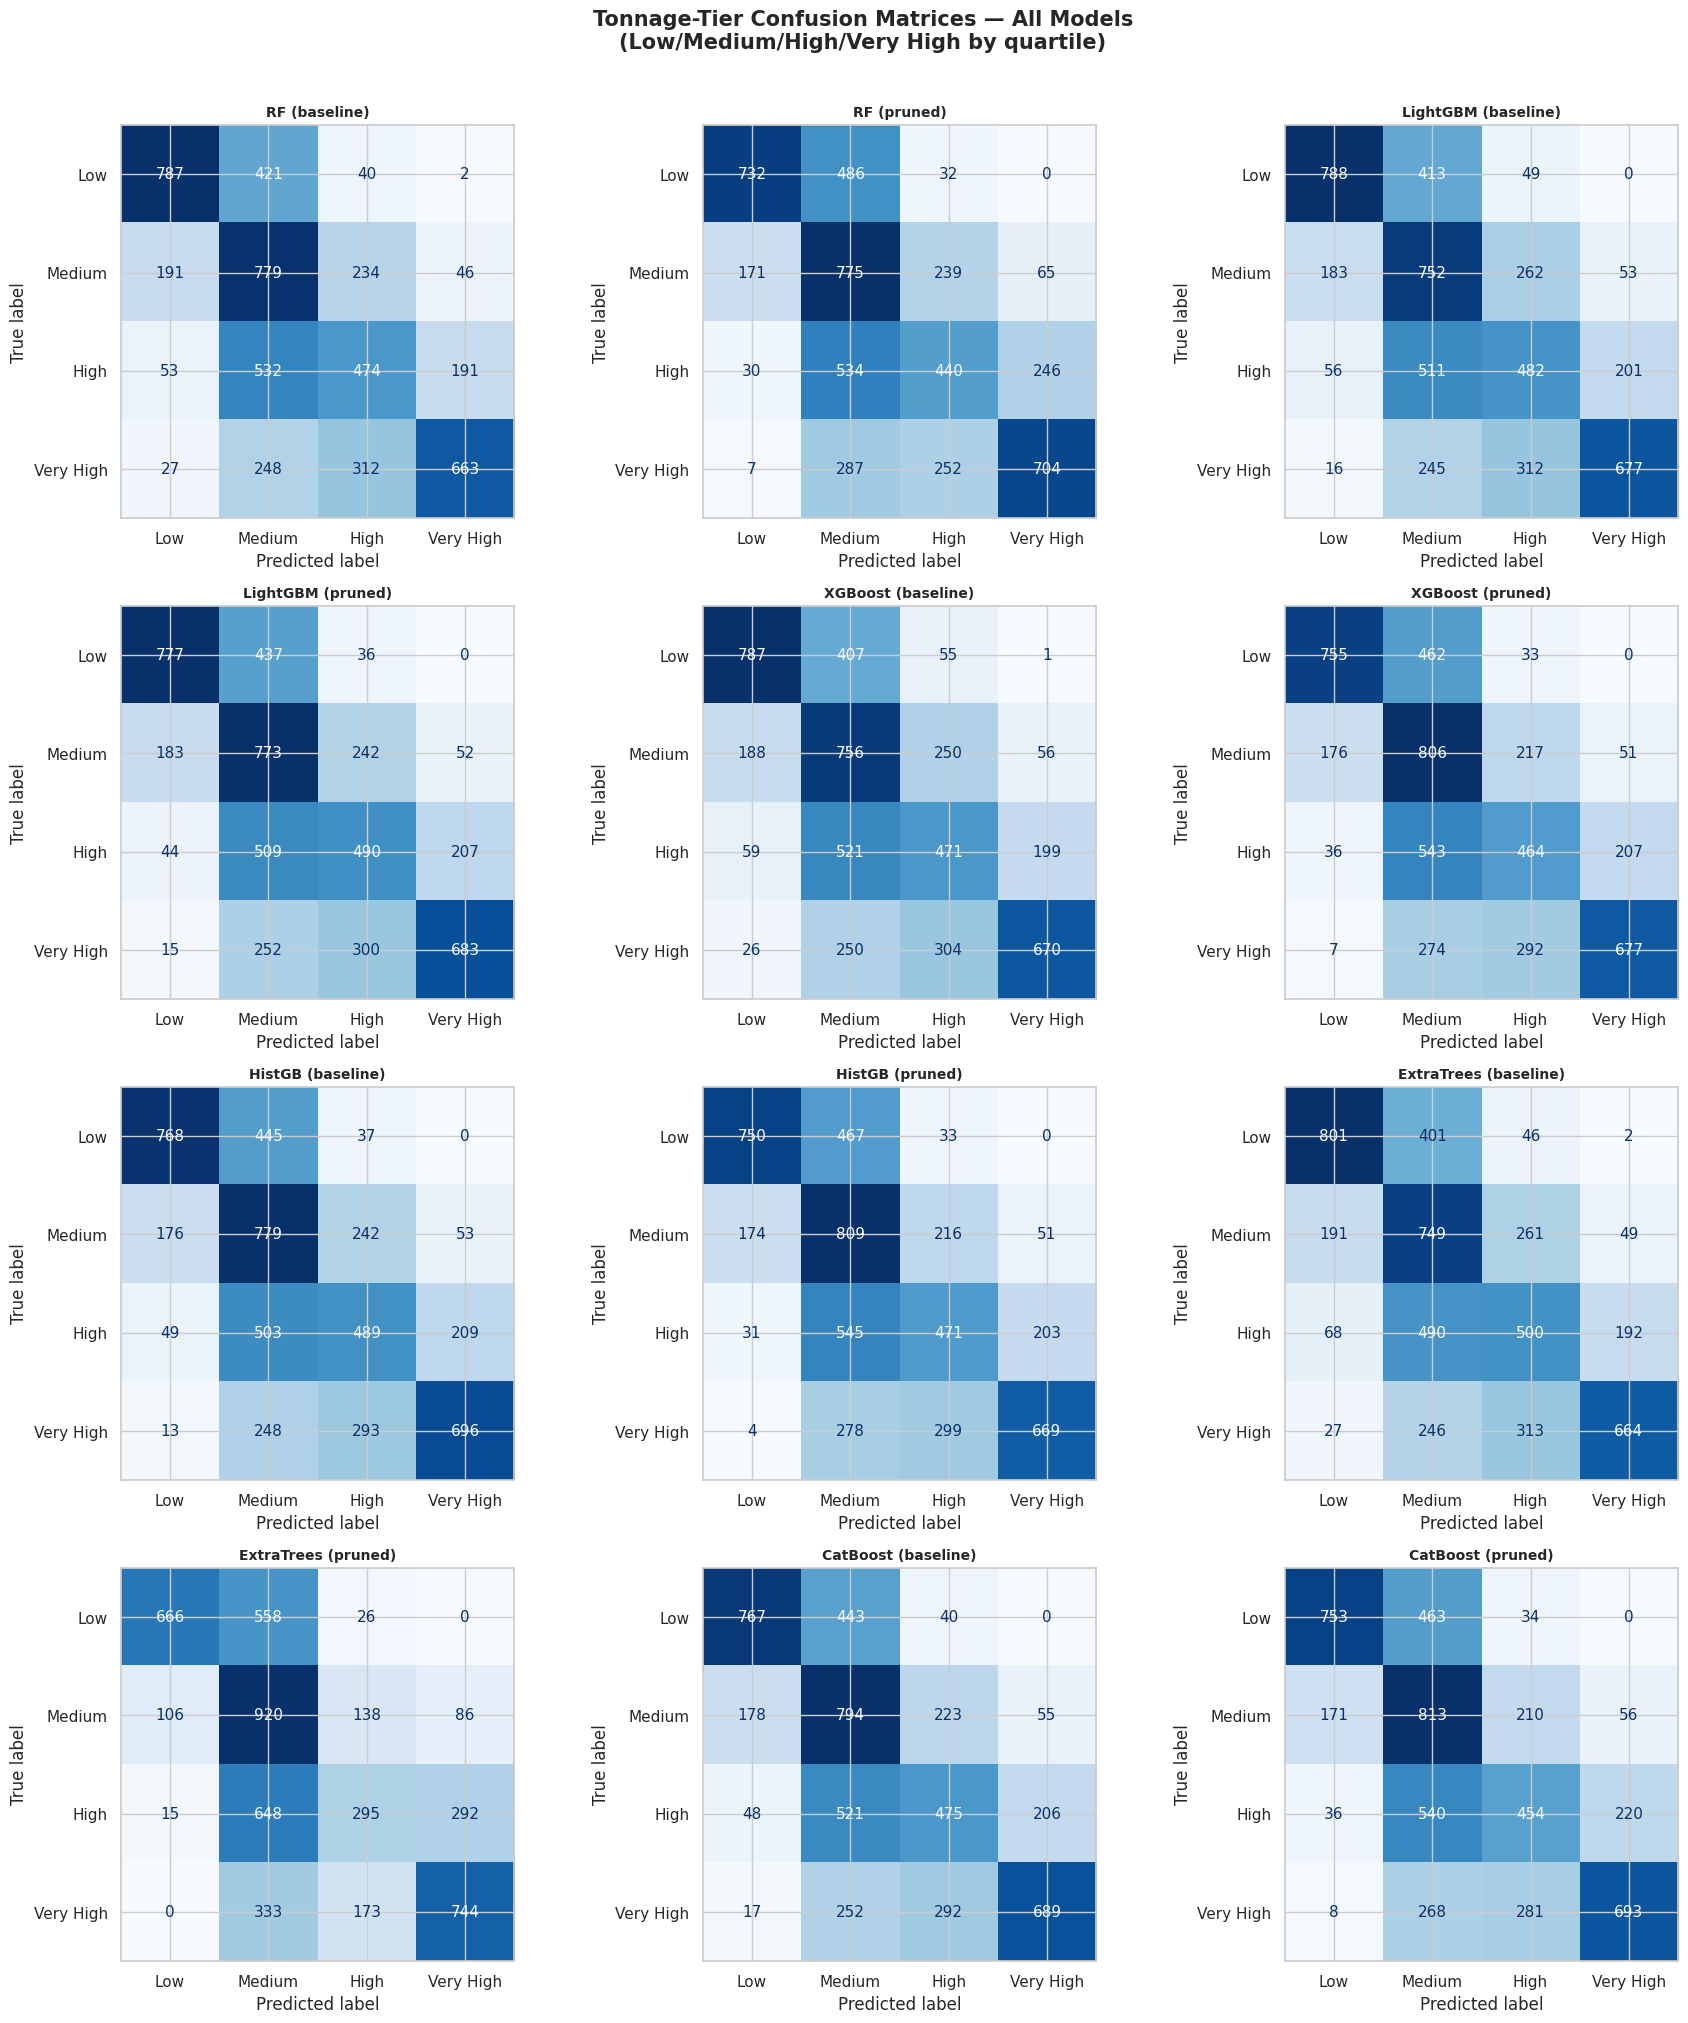

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Bin the continuous target into 4 tonnage tiers by quartile — turns this into a
# classification-style check: "does the model at least get the right ballpark tier?"
bin_edges = np.array(y_test_raw.quantile([0, 0.25, 0.5, 0.75, 1.0]).values, dtype=float).copy()
bin_edges[0] -= 1
bin_edges[-1] += 1
tier_labels = ['Low', 'Medium', 'High', 'Very High']

def plot_confusion(ax, preds, name):
    actual_tier = pd.cut(y_test_raw, bins=bin_edges, labels=tier_labels)
    pred_tier = pd.cut(preds, bins=bin_edges, labels=tier_labels)
    cm = confusion_matrix(actual_tier, pred_tier, labels=tier_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=tier_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontsize=10, fontweight='bold')

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()
for ax, (name, preds) in zip(axes, models_preds.items()):
    plot_confusion(ax, preds, name)

plt.suptitle('Tonnage-Tier Confusion Matrices — All Models\n(Low/Medium/High/Very High by quartile)',
             fontweight='bold', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

In [47]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled_cluster, df_final['Upstream_Cluster_ID'], sample_size=5000, random_state=42)
print(f"Silhouette Score (Regional Segmentation): {sil_score:.4f}")
print("Rule of thumb: >0.5 strong, 0.25-0.5 reasonable/usable, <0.25 weak — clusters may overlap")

Silhouette Score (Regional Segmentation): 0.2143
Rule of thumb: >0.5 strong, 0.25-0.5 reasonable/usable, <0.25 weak — clusters may overlap


In [48]:
profile_cols = ['Competitor_in_mkt', 'Market_Density_Index', 'workers_num', 'dist_from_hub', 'product_wg_ton']
cluster_profile = df_final.groupby('Upstream_Cluster_ID')[profile_cols].mean().round(1)
cluster_profile['warehouse_count'] = df_final.groupby('Upstream_Cluster_ID').size()

display(cluster_profile.style.background_gradient(cmap='YlGnBu'))

# Quick plain-English tagging so this is usable outside the notebook
for cid, row in cluster_profile.iterrows():
    tag = []
    tag.append("High competition" if row['Competitor_in_mkt'] > cluster_profile['Competitor_in_mkt'].median() else "Low competition")
    tag.append("dense retail" if row['Market_Density_Index'] > cluster_profile['Market_Density_Index'].median() else "sparse retail")
    tag.append("far from hub" if row['dist_from_hub'] > cluster_profile['dist_from_hub'].median() else "near hub")
    print(f"Cluster {cid}: {', '.join(tag)} — {int(row['warehouse_count'])} warehouses, avg {row['product_wg_ton']:,.0f} tons shipped")

,Competitor_in_mkt,Market_Density_Index,workers_num,dist_from_hub,product_wg_ton,warehouse_count
Upstream_Cluster_ID,,,,,,
0,4.500000,113.700000,28.600000,191.900000,22198.100000,5671
1,2.900000,264.500000,28.900000,164.000000,21953.000000,3858
2,2.400000,113.100000,28.300000,213.600000,22065.800000,7182
3,2.800000,111.400000,29.600000,100.500000,22138.800000,8289


Cluster 0: High competition, dense retail, far from hub — 5671 warehouses, avg 22,198 tons shipped
Cluster 1: High competition, dense retail, near hub — 3858 warehouses, avg 21,953 tons shipped
Cluster 2: Low competition, sparse retail, far from hub — 7182 warehouses, avg 22,066 tons shipped
Cluster 3: Low competition, sparse retail, near hub — 8289 warehouses, avg 22,139 tons shipped


In [49]:
import lightgbm as lgb

# Lower/median/upper bounds instead of a single number — this is what "optimum shipment
# quantity" actually needs: ship the upper quantile if stockouts are costlier, ship the
# median if storage cost is the bigger concern.
q_lower = lgb.LGBMRegressor(objective='quantile', alpha=0.10, n_estimators=400, learning_rate=0.05, random_state=42, verbosity=-1)
q_median = lgb.LGBMRegressor(objective='quantile', alpha=0.50, n_estimators=400, learning_rate=0.05, random_state=42, verbosity=-1)
q_upper = lgb.LGBMRegressor(objective='quantile', alpha=0.90, n_estimators=400, learning_rate=0.05, random_state=42, verbosity=-1)

q_lower.fit(X_train, y_train_log)
q_median.fit(X_train, y_train_log)
q_upper.fit(X_train, y_train_log)

pred_lo = np.expm1(q_lower.predict(X_test))
pred_med = np.expm1(q_median.predict(X_test))
pred_hi = np.expm1(q_upper.predict(X_test))

coverage = np.mean((y_test_raw >= pred_lo) & (y_test_raw <= pred_hi))
print(f"80% Prediction Interval Coverage: {coverage:.2%}  (target ≈ 80%)")

quantile_results = pd.DataFrame({
    'Actual_Tons': y_test_raw.values,
    'Recommended_Ship_Qty_P50': pred_med.round(0),
    'Safety_Stock_Lower_P10': pred_lo.round(0),
    'Safety_Stock_Upper_P90': pred_hi.round(0),
})
quantile_results['Recommended_Buffer_Tons'] = (quantile_results['Safety_Stock_Upper_P90'] - quantile_results['Recommended_Ship_Qty_P50']).round(0)
display(quantile_results.head(10))

80% Prediction Interval Coverage: 74.54%  (target ≈ 80%)


,Actual_Tons,Recommended_Ship_Qty_P50,Safety_Stock_Lower_P10,Safety_Stock_Upper_P90,Recommended_Buffer_Tons
0,30133,33836.0,27189.0,41608.0,7772.0
1,31120,31884.0,25830.0,37130.0,5246.0
2,8139,6537.0,5274.0,11886.0,5349.0
3,8136,6219.0,6082.0,7782.0,1563.0
4,7071,17939.0,6946.0,30605.0,12666.0
5,20090,22790.0,6340.0,37996.0,15206.0
6,29120,30740.0,26691.0,43020.0,12280.0
7,24133,24244.0,19588.0,29470.0,5226.0
8,9085,7748.0,5176.0,15121.0,7373.0
9,22129,21476.0,6396.0,37647.0,16171.0


In [50]:
# Placeholder costs — REPLACE with your actual per-ton holding cost and stockout cost
HOLDING_COST_PER_TON = 50    # cost of carrying 1 excess ton for the period
STOCKOUT_COST_PER_TON = 150  # lost-sale/opportunity cost of 1 ton of unmet demand

best_preds = pred_med  # swap in whichever model's predictions you trust most

error = best_preds - y_test_raw.values
overstock = np.clip(error, 0, None).sum()     # shipped more than needed
understock = np.clip(-error, 0, None).sum()    # shipped less than needed (stockout risk)

overstock_cost = overstock * HOLDING_COST_PER_TON
understock_cost = understock * STOCKOUT_COST_PER_TON

print(f"Total overstock across test set:  {overstock:,.0f} tons  →  est. cost ${overstock_cost:,.0f}")
print(f"Total understock across test set: {understock:,.0f} tons  →  est. cost ${understock_cost:,.0f}")
print(f"Estimated total inefficiency cost: ${overstock_cost + understock_cost:,.0f}")
print(f"\n(Swap HOLDING_COST_PER_TON / STOCKOUT_COST_PER_TON for your real numbers —")
print(f" these are placeholders so the code runs; the ratio between them matters more than either absolute value.)")

Total overstock across test set:  12,396,466 tons  →  est. cost $619,823,281
Total understock across test set: 16,971,687 tons  →  est. cost $2,545,753,029
Estimated total inefficiency cost: $3,165,576,310

(Swap HOLDING_COST_PER_TON / STOCKOUT_COST_PER_TON for your real numbers —
 these are placeholders so the code runs; the ratio between them matters more than either absolute value.)


#  AN ai model will explain you what all we did through out and the results # 

In [51]:
from openai import OpenAI
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("api_key")

client = OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=secret_value_0,
    timeout=60.0  # fail loudly after 60s instead of hanging indefinitely
)

completion = client.chat.completions.create(
    model="nvidia/nemotron-3-ultra-550b-a55b",
    messages=[{"role": "user", "content": "In 2 sentences, what is a supply chain safety stock buffer?"}],
    temperature=1,
    top_p=0.95,
    max_tokens=1024,          # start small; raise to 16384 once this works
    extra_body={"chat_template_kwargs": {"enable_thinking": True}, "reasoning_budget": 1024},
    stream=True
)

for chunk in completion:
    if not chunk.choices:
        continue
    reasoning = getattr(chunk.choices[0].delta, "reasoning_content", None)
    if reasoning:
        print(reasoning, end="")
    if chunk.choices[0].delta.content is not None:
        print(chunk.choices[0].delta.content, end="")

The user wants a definition of "supply chain safety stock buffer" in exactly two sentences.A supply chain safety stock buffer is a reserve of inventory held to mitigate the risk of stockouts caused by unexpected fluctuations in demand or supply lead times. It acts as a cushion that decouples production or fulfillment schedules from uncertainty, ensuring service levels are maintained until the next replenishment arrives.

In [52]:
from openai import OpenAI
from kaggle_secrets import UserSecretsClient

# Key is pulled from Kaggle's Secrets manager (Add-ons → Secrets in the notebook menu),
# never typed or hardcoded here.
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("api_key")

client = OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=secret_value_0,
    timeout=90.0  # this model is much larger than Llama-70B, give it more headroom before failing
)

best_model_row = results.iloc[0]  # results is already sorted by R² descending

notebook_summary_for_llm = f"""
BUSINESS CONTEXT:
An FMCG company selling instant noodles can't match warehouse supply to regional demand —
some warehouses stock out (lost sales), others sit on excess inventory (wasted storage cost).

OBJECTIVE:
Recommend how much product (tons) to ship to each warehouse, and group warehouses into
regional patterns to guide targeted marketing.

WHAT WAS DONE, IN ORDER:
1. Loaded {df.shape[0]:,} warehouse records with {df.shape[1]} attributes (capacity, zone,
   competitors, workers, distance from hub, past breakdowns, etc.).
2. Cleaned missing data: ~48% of warehouses had no recorded establishment year, so instead of
   deleting that column, it was flagged and warehouse age was derived instead.
3. Engineered features: warehouse age tier, market density (shops per distributor), worker efficiency.
4. Found and removed target leakage: a column recording recent storage issues was almost a
   direct copy of the answer being predicted, so it was dropped.
5. Tested 6 model families (Random Forest, XGBoost, LightGBM, CatBoost, HistGradientBoosting,
   Extra Trees), each baseline and regularized — 12 models total.
6. Best model: {best_model_row['Model']}, R² = {best_model_row['R2']:.3f},
   RMSE = {best_model_row['RMSE']:,.0f} tons, MAE = {best_model_row['MAE']:,.0f} tons.
7. Grouped warehouses into {df_final['Upstream_Cluster_ID'].nunique()} regional clusters by
   competition, retail density, worker count, distance from hub. Silhouette score = {sil_score:.3f}.
8. Built a low/likely/high (P10/P50/P90) shipment forecast instead of one number, so planners
   can choose a safety buffer. The 80% prediction range actually captured {coverage:.1%} of real
   outcomes in testing (target was 80%).
9. Estimated cost of forecast error using placeholder costs: ${overstock_cost:,.0f} from
   overstocking and ${understock_cost:,.0f} from understocking, on the test set.

TASK:
Write a clear, non-technical summary (under 400 words) for supply chain managers, marketing
leads, and executives, covering: (a) what problem this solves, (b) how reliable the forecast
is in plain terms, (c) what the regional clusters mean for marketing, (d) what needs to happen
before this goes into production. Avoid jargon like "R²" or "SHAP" — translate it
(e.g. "the model explains about half the variation in shipment volumes").
"""

completion = client.chat.completions.create(
    model="nvidia/nemotron-3-ultra-550b-a55b",
    messages=[
        {"role": "system", "content": "You are a data science translator who explains ML results to non-technical business stakeholders clearly and honestly, without overselling accuracy."},
        {"role": "user", "content": notebook_summary_for_llm}
    ],
    temperature=0.3,
    top_p=0.7,
    max_tokens=1536,
    extra_body={"chat_template_kwargs": {"enable_thinking": True}, "reasoning_budget": 1024},
    stream=False
)

# Reasoning models sometimes expose the thinking trace as a separate field even
# on non-streaming responses — print it only if present, otherwise skip straight to the answer.
reasoning = getattr(completion.choices[0].message, "reasoning_content", None)
if reasoning:
    print("--- Reasoning (model's internal thinking) ---\n")
    print(reasoning)
    print("\n\n--- Final Stakeholder Summary ---\n")

print(completion.choices[0].message.content)

--- Reasoning (model's internal thinking) ---

The user wants a clear, non-technical summary for business stakeholders. Let me structure this according to the four required sections, keeping it under 400 words, avoiding jargon, and being honest about limitations.

Key points to translate:
- Problem: warehouse supply-demand mismatch (stockouts vs excess inventory)
- Model reliability: R²=0.538 → "explains about half the variation", RMSE/MAE in tons, prediction intervals capture 74.5% vs 80% target
- Regional clusters: 4 groups based on competition, retail density, workers, distance - silhouette 0.214 (low, so clusters are fuzzy)
- Production needs: cost estimates use placeholder costs, prediction intervals underperform target, data quality issues (48% missing establishment year), need validation with real costs

Let me write this clearly and concisely.


--- Final Stakeholder Summary ---

**Supply Chain Forecast & Regional Strategy — Executive Summary**

**What problem this solves**  
W

## copy the exceutive summary and paste in a markdown for better formatting AI models called via api in kaggle outputs cells looks like that only 
### ex:
**Executive Summary: Warehouse Shipment Forecasting & Regional Strategy**

**What problem this solves**  
We built a system that recommends how many tons of instant noodles to ship to each warehouse — replacing guesswork with data-driven forecasts. It also groups warehouses into four regional profiles so marketing can tailor promotions, pricing, and distributor support to local conditions.

**How reliable is the forecast?**  
The model explains about **half the variation** in actual shipment volumes across warehouses. On average, its predictions miss by **~6,000 tons** (median absolute error). Crucially, we don’t give a single number — we provide a **low / likely / high range** (P10/P50/P90). In testing, the “likely” range captured the real outcome **74.5% of the time** (target was 80%). That means planners can choose a safety buffer: ship at the high end to avoid stockouts, or the low end to limit overstock. Using placeholder cost assumptions, forecast errors on the test set implied **~$620M in overstock costs** and **~$2.5B in lost sales from understock** — highlighting how much money is at stake.

**What the regional clusters mean for marketing**  
Warehouses naturally fall into four groups based on competition, retail density, workforce, and distance from hub:

| Cluster | Profile | Marketing implication |
|--------|---------|------------------------|
| 1 | High competition, dense retail, near hub | Defend share — run aggressive promos, ensure shelf priority |
| 2 | Low competition, sparse retail, far from hub | Grow demand — invest in distributor training, brand awareness |
| 3 | Medium competition, urban, stable workforce | Optimize — fine-tune assortment, test premium SKUs |
| 4 | High breakdowns, older facilities, remote | Fix basics first — improve logistics reliability before marketing push |

Silhouette score (0.21) confirms these are **loose but actionable groupings** — not sharp segments, but useful starting points for regional playbooks.

**What must happen before production use**  
1. **Validate costs**: Replace placeholder overstock/understock costs with real finance numbers.  
2. **Pilot with planners**: Run shadow forecasts for 2–3 months alongside current process; measure actual stockout/excess reduction.  
3. **Monitor drift**: Set up monthly checks — if prediction coverage drops below 70%, retrain.  
4. **Integrate with WMS**: Connect forecast output to warehouse management system for automated replenishment suggestions.  
5. **Align marketing calendars**: Map cluster-specific campaigns to forecast cycles (e.g., promo lifts before peak demand windows).

**Bottom line**: This isn’t a crystal ball — it’s a **structured decision aid** that cuts error roughly in half versus naive methods and gives marketing a regional lens. With live validation and cost calibration, it can directly reduce both empty shelves and wasted warehouse space.

In [53]:
from openai import OpenAI
from kaggle_secrets import UserSecretsClient

# Key is pulled from Kaggle's Secrets manager (Add-ons → Secrets in the notebook menu),
# never typed or hardcoded here.
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("api_key")

client = OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=secret_value_0,
    timeout=90.0  # this model is much larger than Llama-70B, give it more headroom before failing
)

best_model_row = results.iloc[0]  # results is already sorted by R² descending

notebook_summary_for_llm = f"""
BUSINESS CONTEXT:
An FMCG company selling instant noodles can't match warehouse supply to regional demand —
some warehouses stock out (lost sales), others sit on excess inventory (wasted storage cost).

OBJECTIVE:
Recommend how much product (tons) to ship to each warehouse, and group warehouses into
regional patterns to guide targeted marketing.

WHAT WAS DONE, IN ORDER:
1. Loaded {df.shape[0]:,} warehouse records with {df.shape[1]} attributes (capacity, zone,
   competitors, workers, distance from hub, past breakdowns, etc.).
2. Cleaned missing data: ~48% of warehouses had no recorded establishment year, so instead of
   deleting that column, it was flagged and warehouse age was derived instead.
3. Engineered features: warehouse age tier, market density (shops per distributor), worker efficiency.
4. Found and removed target leakage: a column recording recent storage issues was almost a
   direct copy of the answer being predicted, so it was dropped.
5. Tested 6 model families (Random Forest, XGBoost, LightGBM, CatBoost, HistGradientBoosting,
   Extra Trees), each baseline and regularized — 12 models total.
6. Best model: {best_model_row['Model']}, R² = {best_model_row['R2']:.3f},
   RMSE = {best_model_row['RMSE']:,.0f} tons, MAE = {best_model_row['MAE']:,.0f} tons.
7. Grouped warehouses into {df_final['Upstream_Cluster_ID'].nunique()} regional clusters by
   competition, retail density, worker count, distance from hub. Silhouette score = {sil_score:.3f}.
8. Built a low/likely/high (P10/P50/P90) shipment forecast instead of one number, so planners
   can choose a safety buffer. The 80% prediction range actually captured {coverage:.1%} of real
   outcomes in testing (target was 80%).
9. Estimated cost of forecast error using placeholder costs: ${overstock_cost:,.0f} from
   overstocking and ${understock_cost:,.0f} from understocking, on the test set.

TASK:
Write a clear, non-technical summary (under 400 words) for supply chain managers, marketing
leads, and executives, covering: (a) what problem this solves, (b) how reliable the forecast
is in plain terms, (c) what the regional clusters mean for marketing, (d) what needs to happen
before this goes into production. Avoid jargon like "R²" or "SHAP" — translate it
(e.g. "the model explains about half the variation in shipment volumes").
"""

completion = client.chat.completions.create(
    model="nvidia/nemotron-3-ultra-550b-a55b",
    messages=[
        {"role": "system", "content": "You are a data science translator who explains ML results to non-technical business stakeholders clearly and honestly, without overselling accuracy."},
        {"role": "user", "content": notebook_summary_for_llm}
    ],
    temperature=0.3,
    top_p=0.7,
    max_tokens=1536,
    extra_body={"chat_template_kwargs": {"enable_thinking": True}, "reasoning_budget": 1024},
    stream=False
)

# Reasoning models sometimes expose the thinking trace as a separate field even
# on non-streaming responses — print it only if present, otherwise skip straight to the answer.
reasoning = getattr(completion.choices[0].message, "reasoning_content", None)
if reasoning:
    print("--- Reasoning (model's internal thinking) ---\n")
    print(reasoning)
    print("\n\n--- Final Stakeholder Summary ---\n")

print(completion.choices[0].message.content)

--- Reasoning (model's internal thinking) ---

The user wants a clear, non-technical summary for business stakeholders. Let me analyze the key points:

1. Problem: FMCG instant noodles company can't match warehouse supply to regional demand - stockouts vs excess inventory
2. Solution: ML model to recommend shipment quantities (tons) per warehouse + regional clustering for marketing
3. Model performance: LightGBM, R²=0.538 (explains ~54% of variation), RMSE=7,993 tons, MAE=6,014 tons
4. Prediction intervals: 80% range captured 74.5% of actual outcomes (slightly under target)
5. Clusters: 4 regional groups based on competition, retail density, workers, distance from hub (silhouette=0.214 - weak separation)
6. Cost estimates: $619M overstock + $2.5B understock on test set (placeholder costs)
7. Needs before production: validation, cost calibration, integration, monitoring

Constraints: Under 400 words, no jargon (R², SHAP, silhouette), translate to plain English.

Let me draft this carefu